# T78 — Continent-scale porphyry-Cu prospectivity maps: where AND when

**Cluster K: Mineral exploration.**

*Based on:* Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted, *Geology*) — *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows.* Plate model: Alfonso et al. (2024).

## What this notebook does

T17 tells the per-deposit story: at each of two case-study deposits (Safford, Glacier Peak) we read the ML model's Prospectivity Score as a time-series and see when its peak lines up with the deposit's actual mineralisation age. T18 zooms out to the continent scale and asks the complementary question: **across the whole North American Cordillera, WHERE and WHEN were the fertility windows open?**

The paper trains two complementary ML models:

- A **SPATIAL** model on modern (0 Ma) features only — answers "given today's plate margin, where would a porphyry-Cu deposit form now?"
- A **SPATIOTEMPORAL** model on the full Cenozoic feature history — answers "at each grid cell, across all Cenozoic ages sampled, what was the MAXIMUM Prospectivity Score that cell ever reached?"

Both are then ensembled into a **HYPERDIMENSIONAL** prospectivity map — the paper's operational exploration recommendation.

**Sections:**
1. **§1** First principles: what data go into the ML models and what the Prospectivity Score represents.
2. **§2** Load Alfonso 2024 + all 397 North American porphyry-Cu deposits.
3. **§3** Present-day SPATIAL prospectivity map (Cordillera only): what today's plate margin says about porphyry-Cu potential, with all deposits overlaid at their present-day positions.
4. **§4** SPATIOTEMPORAL max-prospectivity map (global grid, focus on North America): the peak Prospectivity Score any grid cell ever reached across the Cenozoic — captures the transient-fertility-window signal at continent scale.
5. **§5** HYPERDIMENSIONAL prospectivity map: the ensemble of spatial + spatiotemporal, i.e. the paper's headline recommendation for future exploration.
6. **§6** Spatiotemporal MINUS spatial: where does time-integration change the recommendation? Highlights belts that were fertile in the past but aren't at modern-margin features alone — legacy deposits + exploration targets that a spatial-only model would miss.
7. **§7** Success-rate curve: the standard mineral-exploration evaluation metric — fraction of known deposits captured within the top-N% of prospectivity area. Compare spatial vs spatiotemporal.
8. **§8** Feature-importance ranking (permutation importance from the paper's own trained model), grouped by tectonic category — Crustal Thickness, Material Input to Trench, Trench Kinematics, Plate & Slab Kinematics, Slab Geometry & Architecture — plus a plain-language dictionary of what every one of the 31 features actually measures.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: \~2 min end-to-end.


## Data availability

**Prospectivity NetCDFs** — three gridded outputs from Norbisrath et al.'s ML training, bundled under `data/deep_time_porphyry/`:

- `spatial_prospectivity.nc` (5 MB, 811 × 787, \~2 km resolution) — North American Cordillera only, spatial model output at 0 Ma.
- `spatiotemporal_max_prospectivity.nc` (7.5 MB, 652 × 1439, \~0.25° resolution) — global grid, the maximum Prospectivity Score any grid cell reached across all Cenozoic ages sampled. Variable: `max_prospectivity`.
- `integrated_hyperdimensional_prospectivity.nc` (7.5 MB, same shape) — the ensembled spatial + spatiotemporal recommendation.

**Model evaluation** — `spatial_success_rate_curve.csv` and `spatiotemporal_success_rate_curve.csv` document deposits-found vs area-fraction (the standard mineral-exploration success-rate curve).

**Feature importance** — `spatiotemporal_feature_importance.csv` (31 features, permutation importance mean + std, feature group) and its `spatial_feature_importance.csv` sibling. From Satyam's `MachineLearningModel.ipynb` runs.

**Deposit inventory** — the same `porphyry_copper_deposits.csv` T17 uses (397 rows).

**Plate model** — Alfonso et al. (2024) via the Plate Model Manager.

**License**: All data are CC BY-NC 4.0 (Norbisrath et al. Zenodo bundle).

## Sources

- Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted 2026) *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows.* *Geology*.
- Alfonso, C.P., Müller, R.D., Mather, B. & Anthony, M. (2024) Spatio-temporal copper prospectivity in the American Cordillera predicted by positive-unlabeled machine learning. *GSA Bulletin*. doi:10.1130/B37614.1.
- Mather, B.R., Müller, R.D., Alfonso, C., Wright, N.M., Seton, M. (2025) Subducting seafloor anomalies promote porphyry copper formation. *International Geology Review* 67(19), 2170-2186. — background reading for T77 (SW-Pacific porphyry belt with the same Alfonso 2024 workflow).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr

import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.11.15
  numpy       2.4.4
  pandas      3.0.2
  xarray      2026.7.0
  gplately    2.0.0
  pygmt       v0.17.0
  pygplates   1.0.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + anchor plate for reconstructing deposit positions.
MODEL_NAME             = "Alfonso2024"
ANCHOR_PLATE_ID        = 0

# Deposit inventory (shared with T17).
DEPOSIT_CSV            = Path("data/deep_time_porphyry/porphyry_copper_deposits.csv")

# Prospectivity NetCDFs (bundled with the suite).
SPATIAL_NC             = Path("data/deep_time_porphyry/spatial_prospectivity.nc")
SPATIOTEMPORAL_MAX_NC  = Path("data/deep_time_porphyry/spatiotemporal_max_prospectivity.nc")
HYPERDIMENSIONAL_NC    = Path("data/deep_time_porphyry/integrated_hyperdimensional_prospectivity.nc")

# Evaluation + feature-importance CSVs.
SPATIAL_SUCCESS_CSV      = Path("data/deep_time_porphyry/spatial_success_rate_curve.csv")
SPATIOTEMPORAL_SUCCESS_CSV = Path("data/deep_time_porphyry/spatiotemporal_success_rate_curve.csv")
SPATIOTEMPORAL_FI_CSV    = Path("data/deep_time_porphyry/spatiotemporal_feature_importance.csv")

# Map regions.
REGION_CORDILLERA      = [-160, -60, 10, 65]      # continent-scale zoom
REGION_GLOBAL          = [-180, 180, -60, 80]     # global map

# CPT range for prospectivity maps (batlow, 0-1). +ef arrow indicates saturation.
PROS_CPT_MAX           = 1.0
PROS_CPT_STEP          = 0.05
# ============================================================================
print(f"  plate model:  {MODEL_NAME}")
print(f"  deposits:     {DEPOSIT_CSV.name}")
print(f"  spatial:      {SPATIAL_NC.name}")
print(f"  spatiotemp.:  {SPATIOTEMPORAL_MAX_NC.name}")
print(f"  hyperdim.:    {HYPERDIMENSIONAL_NC.name}")


  plate model:  Alfonso2024
  deposits:     porphyry_copper_deposits.csv
  spatial:      spatial_prospectivity.nc
  spatiotemp.:  spatiotemporal_max_prospectivity.nc
  hyperdim.:    integrated_hyperdimensional_prospectivity.nc


## 1. First principles: what the ML models learn

The paper's ML pipeline is a **positive-unlabelled (PU) bagging classifier** — a standard technique for mineral prospectivity when you have known deposits ("positive" examples) but no confirmed non-deposits (the "unlabelled" class, because absence of a known deposit doesn't prove there isn't one waiting to be discovered).

**Training samples**

- **Positive class** — the 397 well-documented North American porphyry-Cu deposits (the same inventory §2 loads). For the SPATIAL model, each deposit contributes one sample at its present-day (lon, lat, 0 Ma) coordinates. For the SPATIOTEMPORAL model, each deposit contributes a trajectory — a sequence of (paleo-lon, paleo-lat, age) samples along the deposit's plate-motion history through the Cenozoic.
- **Unlabelled class** — random points sampled across the North American Cordillera at present-day (spatial model) or across (paleo-lon, paleo-lat, age) trajectories (spatiotemporal model). These represent "places where no porphyry-Cu deposit is currently known" — some of them may hide undiscovered deposits, which is why they're unlabelled rather than treated as confirmed negatives.

**Features (31 total)**

At each training sample, 31 tectonic features are sampled from Norbisrath et al.'s deep-time reconstruction pipeline (built on top of Alfonso 2024's plate model). These fall into five categories — plain-language descriptions of each feature are given in §8:

- **Crustal Thickness** (6 features) — statistics of the over-riding continental crust in a spatial kernel (mean, median, max, min, std, range).
- **Material Input to Trench** (11 features) — what the subducting slab delivers to the arc: carbonate + sediment + water + CO₂ thicknesses and volumes, seafloor age, spreading rate, slab flux.
- **Trench Kinematics** (4 features) — how the trench itself is moving in the mantle frame.
- **Plate & Slab Kinematics** (8 features) — plate convergence and absolute plate motions.
- **Slab Geometry & Architecture** (2 features) — slab dip and arc-trench distance.

**Prospectivity Score = model's posterior ranking**

Given the 31 feature values at any query point, the trained model returns a value in [0, 1] that represents *"how likely is this point to belong to the positive (deposit) class, given the tectonic setting sampled?"* A score near 1 means the tectonic setting matches known deposits closely; a score near 0 means it's unlike any known deposit. Because it's a PU classifier, the exact numeric value isn't a true probability — it's a well-behaved ranking that maps monotonically to prospectivity.

**Where the three grids in this notebook come from**

- **`spatial_prospectivity.nc`** — the SPATIAL model applied to every (lon, lat) grid cell in the North American Cordillera, using features sampled at 0 Ma. This is what you'd get from a modern-margin-only analysis.
- **`spatiotemporal_max_prospectivity.nc`** — the SPATIOTEMPORAL model applied to every (paleo-lon, paleo-lat) trajectory across the Cenozoic; then for each grid cell, the MAXIMUM Prospectivity Score reached across all age slices. Captures the transient-fertility-window signal.
- **`integrated_hyperdimensional_prospectivity.nc`** — the ensembled recommendation combining both. This is the paper's operational exploration map.

The rest of the notebook loads these grids, visualises and diffs them, evaluates the models' success-rate curves against the known deposits, and ranks the 31 features by permutation importance to identify the tectonic controls the model relies on.


## 2. Load plate model + North American deposit inventory


In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

# PMM sometimes returns a list of rotation paths — wrap if needed
_pmm_rot = model.get_rotation_model()
if not hasattr(_pmm_rot, "get_rotation"):
    rotation_model = pygplates.RotationModel(_pmm_rot)
else:
    rotation_model = _pmm_rot

recon = gplately.PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  plate model loaded: {MODEL_NAME}")

# Load deposit inventory
deposits = pd.read_csv(DEPOSIT_CSV)
print(f"  loaded {len(deposits):,} porphyry-Cu deposits from {DEPOSIT_CSV.name}")
AGE_SENTINEL = -9999.0
dated = deposits.loc[deposits["age_ma"] != AGE_SENTINEL].reset_index(drop=True)
print(f"  {len(dated):,} deposits have a published mineralisation age "
      f"({len(deposits) - len(dated):,} carry the -9999 sentinel)")

# Reconstruct each dated deposit to its OWN mineralisation age
_plon, _plat = [], []
for _, row in dated.iterrows():
    try:
        gp = gplately.Points(recon,
                              [float(row["longitude"])],
                              [float(row["latitude"])],
                              anchor_plate_id=ANCHOR_PLATE_ID)
        rl, ra = gp.reconstruct(float(row["age_ma"]),
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
        _plon.append(float(rl[0]) if len(rl) else np.nan)
        _plat.append(float(ra[0]) if len(ra) else np.nan)
    except Exception:
        _plon.append(np.nan); _plat.append(np.nan)
dated = dated.assign(paleo_lon=_plon, paleo_lat=_plat)
dated_ok = dated.dropna(subset=["paleo_lon", "paleo_lat"]).copy()
print(f"  ✓ {len(dated_ok):,} deposits reconstructed cleanly to their formation age")


  plate model loaded: Alfonso2024
  loaded 471 porphyry-Cu deposits from porphyry_copper_deposits.csv
  293 deposits have a published mineralisation age (178 carry the -9999 sentinel)


  ✓ 293 deposits reconstructed cleanly to their formation age


## 3. Present-day SPATIAL prospectivity map

The paper's SPATIAL ML model was trained on features sampled at present-day (0 Ma) positions of all known North American porphyry-Cu deposits. It answers the question: *"given the modern configuration of the Cordilleran subduction margin, where SHOULD porphyry-Cu deposits be?"* Modern deposits at their present-day positions are overlaid; a good spatial model puts most of the hot pixels near the known deposits.


  spatial prospectivity: shape=(811, 787), finite=283,141 pixels, range=[0.000, 1.000]


  (skip continent overlay: AttributeError)


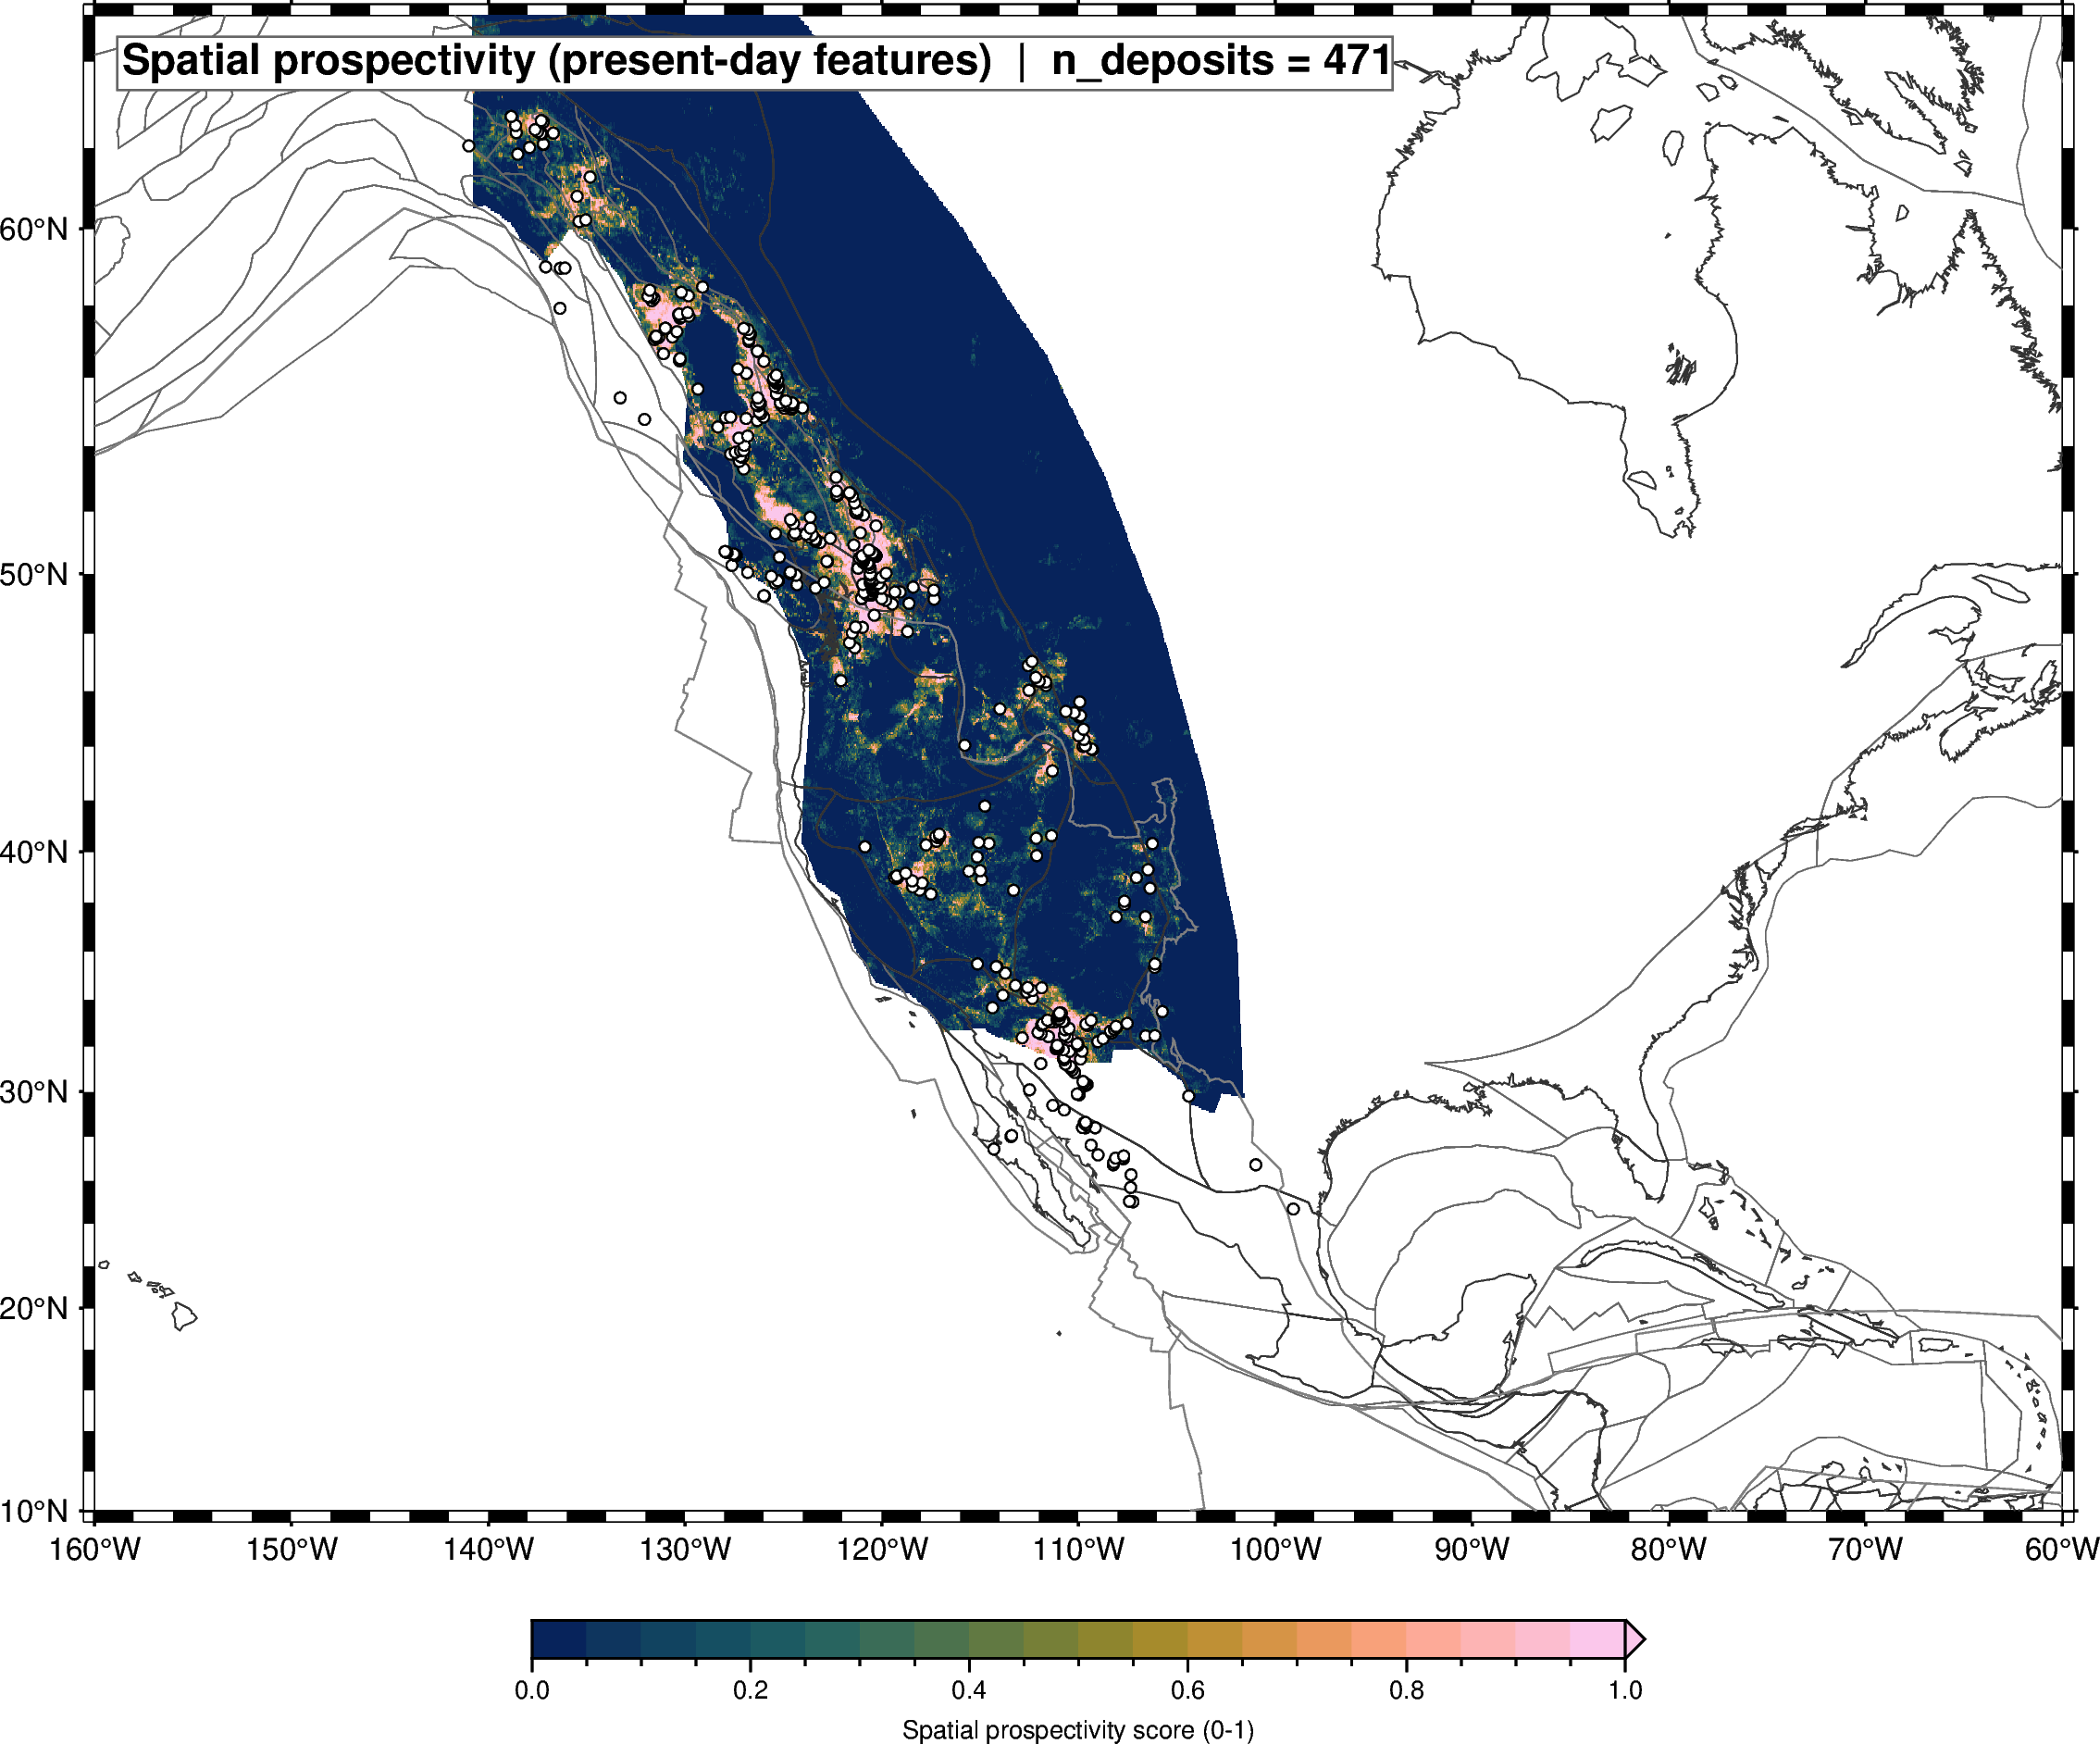

In [4]:
_ds = xr.open_dataset(SPATIAL_NC)
_vn = list(_ds.data_vars)[0]
spatial_da = _ds[_vn]
print(f"  spatial prospectivity: shape={spatial_da.shape}, "
      f"finite={int(np.isfinite(spatial_da.values).sum()):,} pixels, "
      f"range=[{float(spatial_da.min()):.3f}, {float(spatial_da.max()):.3f}]")

# PlotTopologies at 0 Ma for coastline + subduction-zone overlay
gplot_0 = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=0.0,
    plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
fig.basemap(region=REGION_CORDILLERA, projection="M18c", frame="af")

# Base: batlow prospectivity raster
pygmt.makecpt(cmap="batlow",
               series=[0, PROS_CPT_MAX, PROS_CPT_STEP],
               background="o")
try:
    fig.grdimage(grid=spatial_da, cmap=True, nan_transparent=True)
except Exception as e:
    print(f"  (skip grdimage: {type(e).__name__})")

# Continent + plate topology overlay
try:
    gplot_0.plot_continents(fig, fill=None, pen="0.3p,gray40")
    gplot_0.plot_coastlines(fig, pen="0.35p,gray20")
    gplot_0.plot_all_topological_sections(fig, pen="0.4p,gray50")
    (_tl, _tr) = gplot_0.get_subduction_direction()
    gplot_0.plot_subduction_zones(fig, _tl, _tr, color="red")
except Exception as e:
    print(f"  (skip continent overlay: {type(e).__name__})")

# All 397 deposits at PRESENT-DAY positions (spatial model uses modern coords)
fig.plot(x=deposits["longitude"], y=deposits["latitude"],
          style="c0.10c", fill="white", pen="0.4p,black")

# Colour bar
fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1c+ef",
              frame=["xa0.2f0.05+lSpatial prospectivity score (0-1)"])

fig.text(text=f"Spatial prospectivity (present-day features)  |  n_deposits = {len(deposits)}",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.show(width=1100)


### How to read this map

- **Batlow raster** — the SPATIAL Prospectivity Score at each grid cell, 0 (dark blue, unlike any known deposit's tectonic setting) → 1 (bright yellow, tectonic setting closely matches known deposits). The `+ef` arrow at the right end of the colour bar signals that any values above 1.0 saturate; in practice the model output is bounded at 1.
- **White dots** — all 397 known North American porphyry-Cu deposits at their **present-day** coordinates. The spatial model was trained on features sampled at these present-day positions, so overlaying them tests whether the model puts hot pixels where the known deposits actually are.
- **Red teeth** — modern subduction zones from Alfonso 2024's plate topology. Porphyry-Cu formation requires an active or recently-active subduction zone, so hot pixels should hug these.

**What it means**

This map answers *"given today's plate margin, where SHOULD porphyry-Cu deposits be RIGHT NOW?"* — it's a snapshot analysis using only modern feature values. A working spatial model produces bright yellow patches near where the white dots cluster (models known deposits) and near quiet-modern areas that share the same tectonic recipe (models undiscovered ones).

**Watch for**

- **Bright pixels WITHOUT a nearby white dot** — exploration targets the spatial model recommends but no known deposit exists yet.
- **A white dot in dark blue** — a known deposit whose modern tectonic surroundings don't match the spatial model's recipe. That deposit likely formed under different (past) conditions — a clue that time-integration will matter (see §4 next).


## 4. Spatiotemporal MAX-prospectivity map

For each grid cell, the paper's SPATIOTEMPORAL model evaluates the Prospectivity Score at every Cenozoic age slice, then keeps the maximum. Cells that were prospective at ANY point in the Cenozoic light up here, even if their modern-margin features would score low today. This is the map that captures **transient fertility windows** at continent scale — the belts that were fertile once and left a deposit record even if the fertility window has since closed.

Now the deposits are shown at their PALEO-positions (their location at the time of mineralisation), so a working spatiotemporal model puts deposits on top of the yellow patches.


grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline


  spatiotemporal max: shape=(652, 1439), finite=148,880 pixels, range=[0.000, 1.000]


  (skip continent overlay: AttributeError)


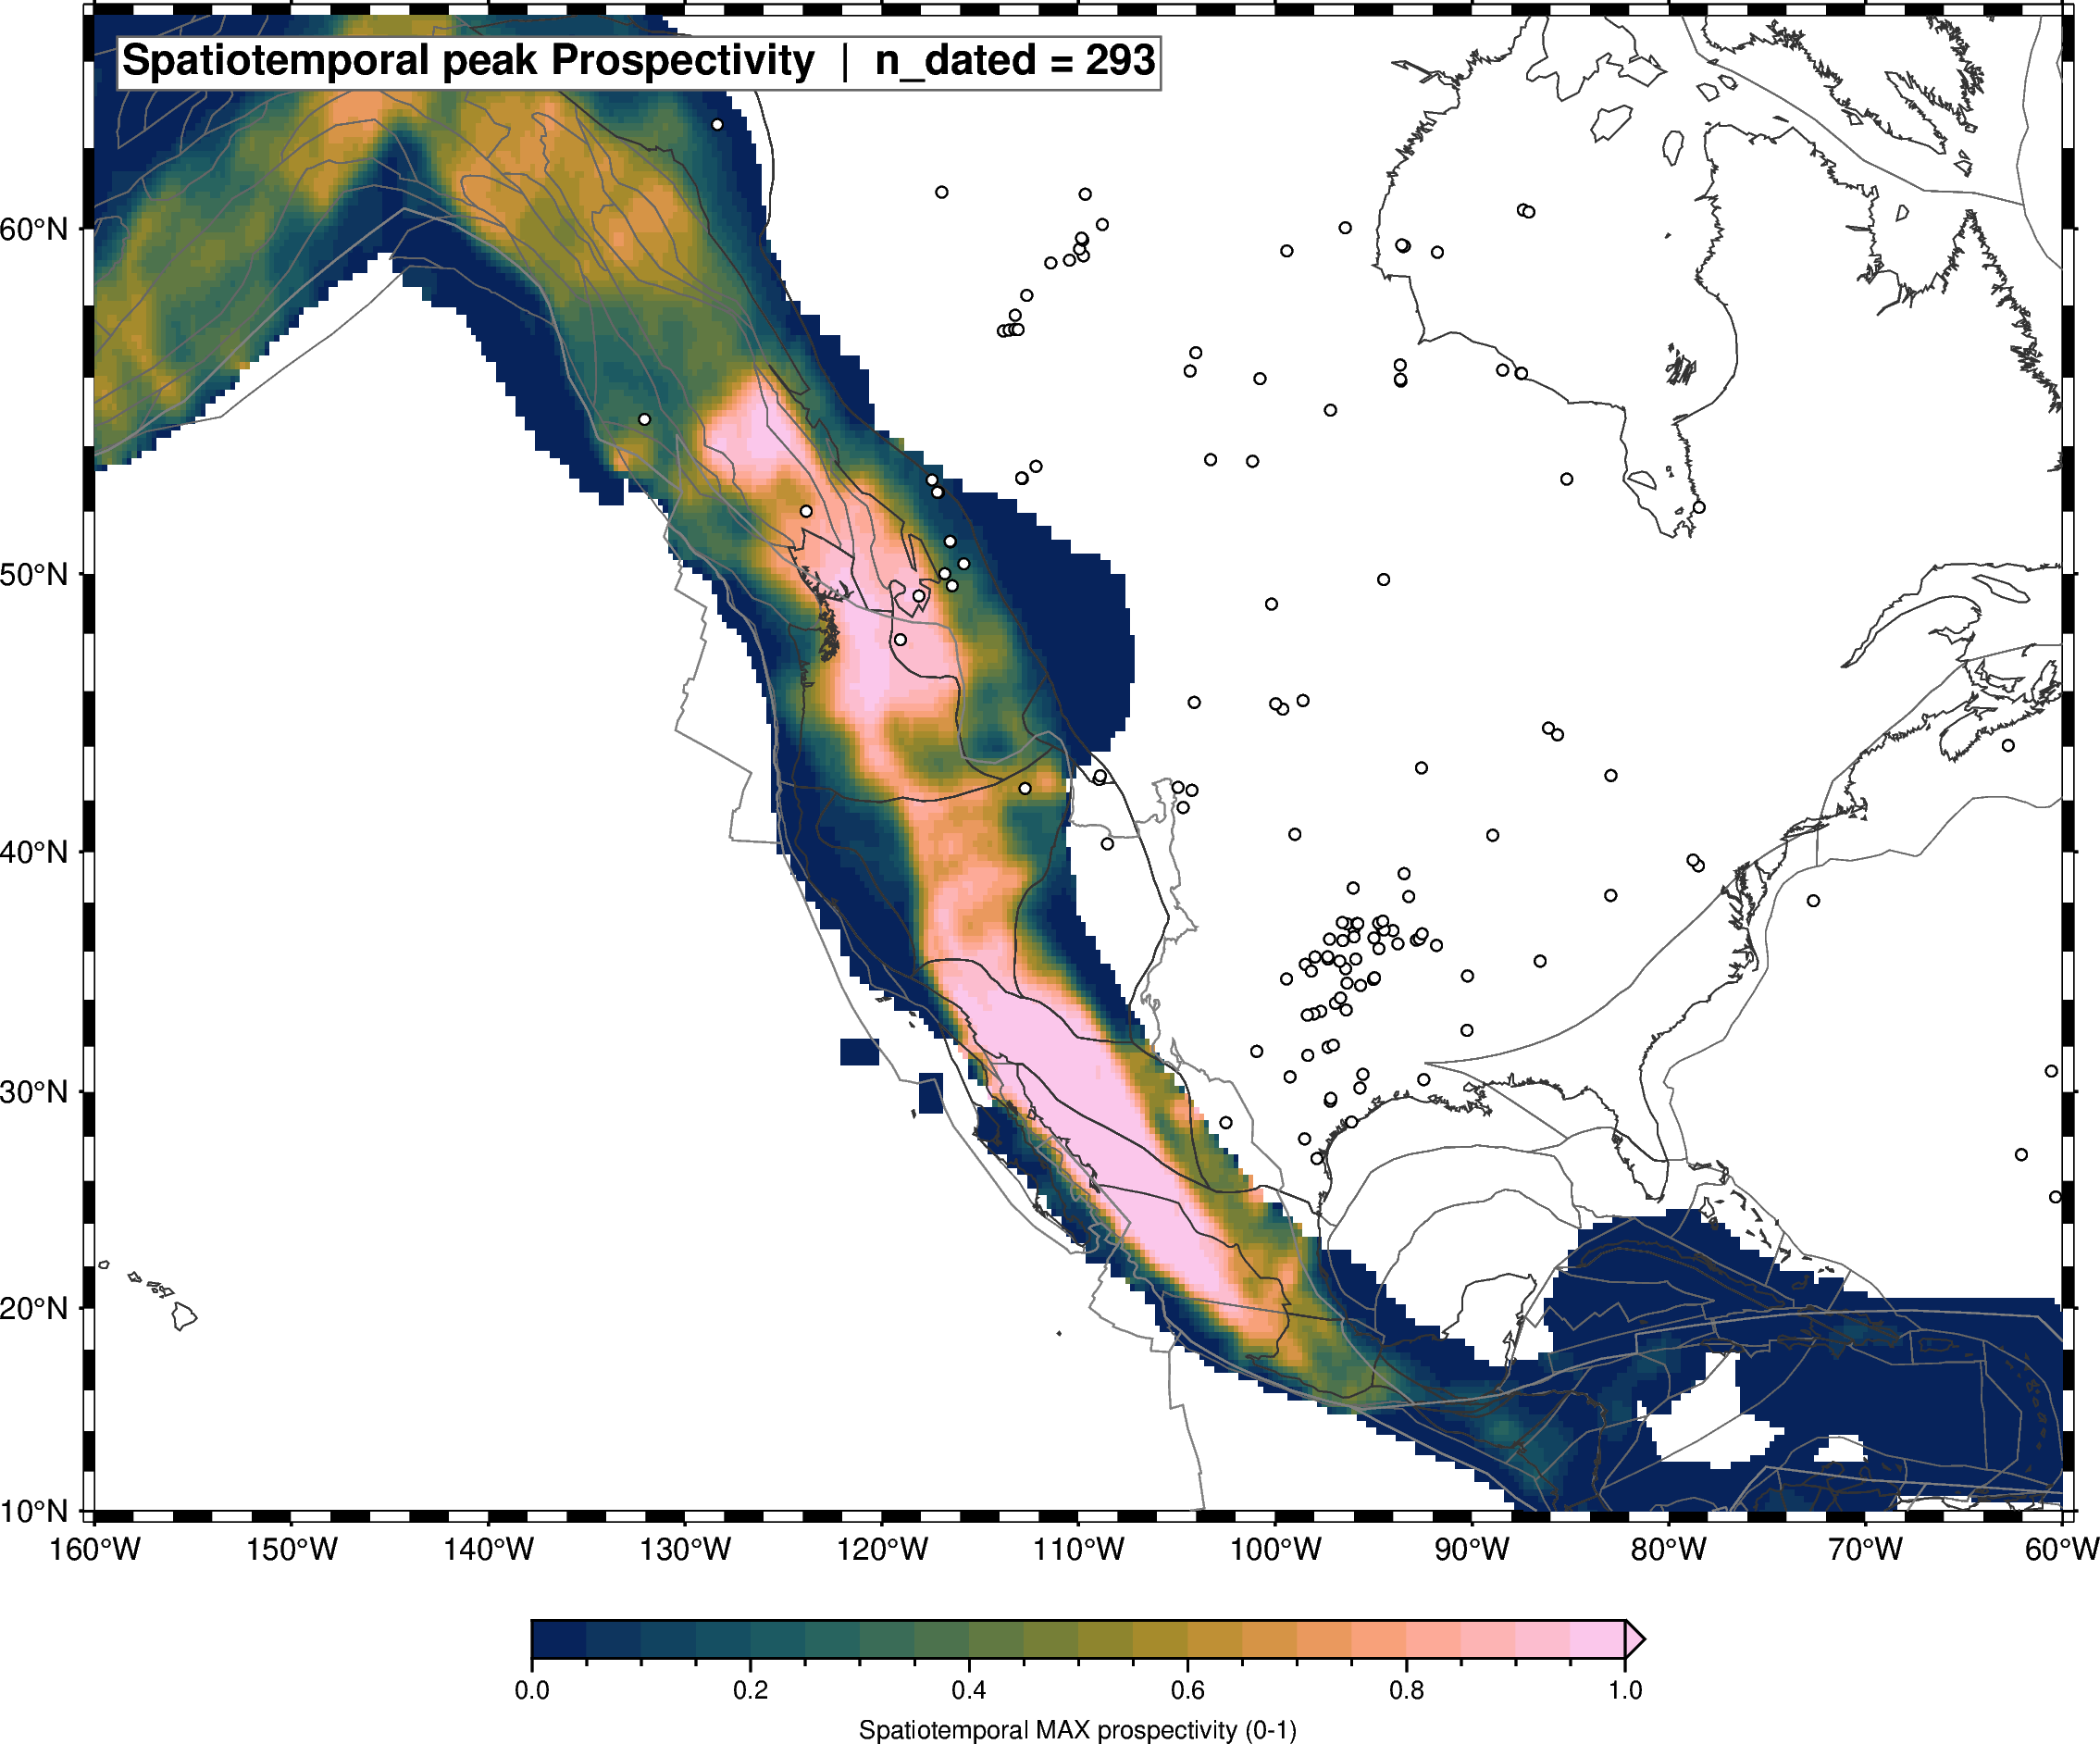

In [5]:
_ds = xr.open_dataset(SPATIOTEMPORAL_MAX_NC)
stemp_da = _ds["max_prospectivity"]
print(f"  spatiotemporal max: shape={stemp_da.shape}, "
      f"finite={int(np.isfinite(stemp_da.values).sum()):,} pixels, "
      f"range=[{float(stemp_da.min()):.3f}, {float(stemp_da.max()):.3f}]")

fig = pygmt.Figure()
fig.basemap(region=REGION_CORDILLERA, projection="M18c", frame="af")

pygmt.makecpt(cmap="batlow",
               series=[0, PROS_CPT_MAX, PROS_CPT_STEP],
               background="o")
try:
    fig.grdimage(grid=stemp_da, cmap=True, nan_transparent=True)
except Exception as e:
    print(f"  (skip grdimage: {type(e).__name__})")

try:
    gplot_0.plot_continents(fig, fill=None, pen="0.3p,gray40")
    gplot_0.plot_coastlines(fig, pen="0.35p,gray20")
    gplot_0.plot_all_topological_sections(fig, pen="0.4p,gray50")
    (_tl, _tr) = gplot_0.get_subduction_direction()
    gplot_0.plot_subduction_zones(fig, _tl, _tr, color="red")
except Exception as e:
    print(f"  (skip continent overlay: {type(e).__name__})")

# Deposits at their PALEO-positions (reconstructed to formation age)
fig.plot(x=dated_ok["paleo_lon"], y=dated_ok["paleo_lat"],
          style="c0.10c", fill="white", pen="0.4p,black")

fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1c+ef",
              frame=["xa0.2f0.05+lSpatiotemporal MAX prospectivity (0-1)"])

fig.text(text=f"Spatiotemporal peak Prospectivity  |  n_dated = {len(dated_ok)}",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.show(width=1100)


### How to read this map

- **Batlow raster** — the MAXIMUM Prospectivity Score any grid cell reached across the paper's Cenozoic time slices. A cell lights up if it was ever fertile at ANY age, even if its modern features look uninteresting.
- **White dots** — the 293 dated deposits at their **paleo-position** (each reconstructed via Alfonso 2024 to its own mineralisation age). Because both the map value AND the deposit position are now on a paleogeographic footing, a working spatiotemporal model puts hot pixels under the paleo-positions.

**What it means**

This is the map the paper's "transient fertility windows" hypothesis actually predicts. If porphyry-Cu formation only requires favourable tectonic conditions BRIEFLY (for a few Myr per belt across the Cenozoic), then a MAX-over-time map should light up wherever those brief fertility windows opened — even if the belt is now tectonically quiet.

**Watch for**

- **Along-margin fertility belts** — the Cordillera should show a coherent north-south fertile stripe reflecting different age slices lighting up different segments (Laramide belt older, Basin & Range belt younger).
- **Fertility that DOESN'T match §3** — cells that are yellow here but dark in §3 are the crux of §6 (the spatial ↔ spatiotemporal diff). They're the "past fertility, quiet-modern" targets.


## 5. HYPERDIMENSIONAL integrated prospectivity map

The paper's operational recommendation ensembles the spatial and spatiotemporal models into a hyperdimensional prospectivity grid. A cell is highlighted if EITHER model finds it prospective — spatial catches "prospective at modern margin features", spatiotemporal catches "prospective at some Cenozoic age". This is the map exploration geologists actually use.


grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline


  hyperdimensional: shape=(652, 1439), finite=7,423 pixels, range=[0.000, 0.886]


  (skip continent overlay: AttributeError)


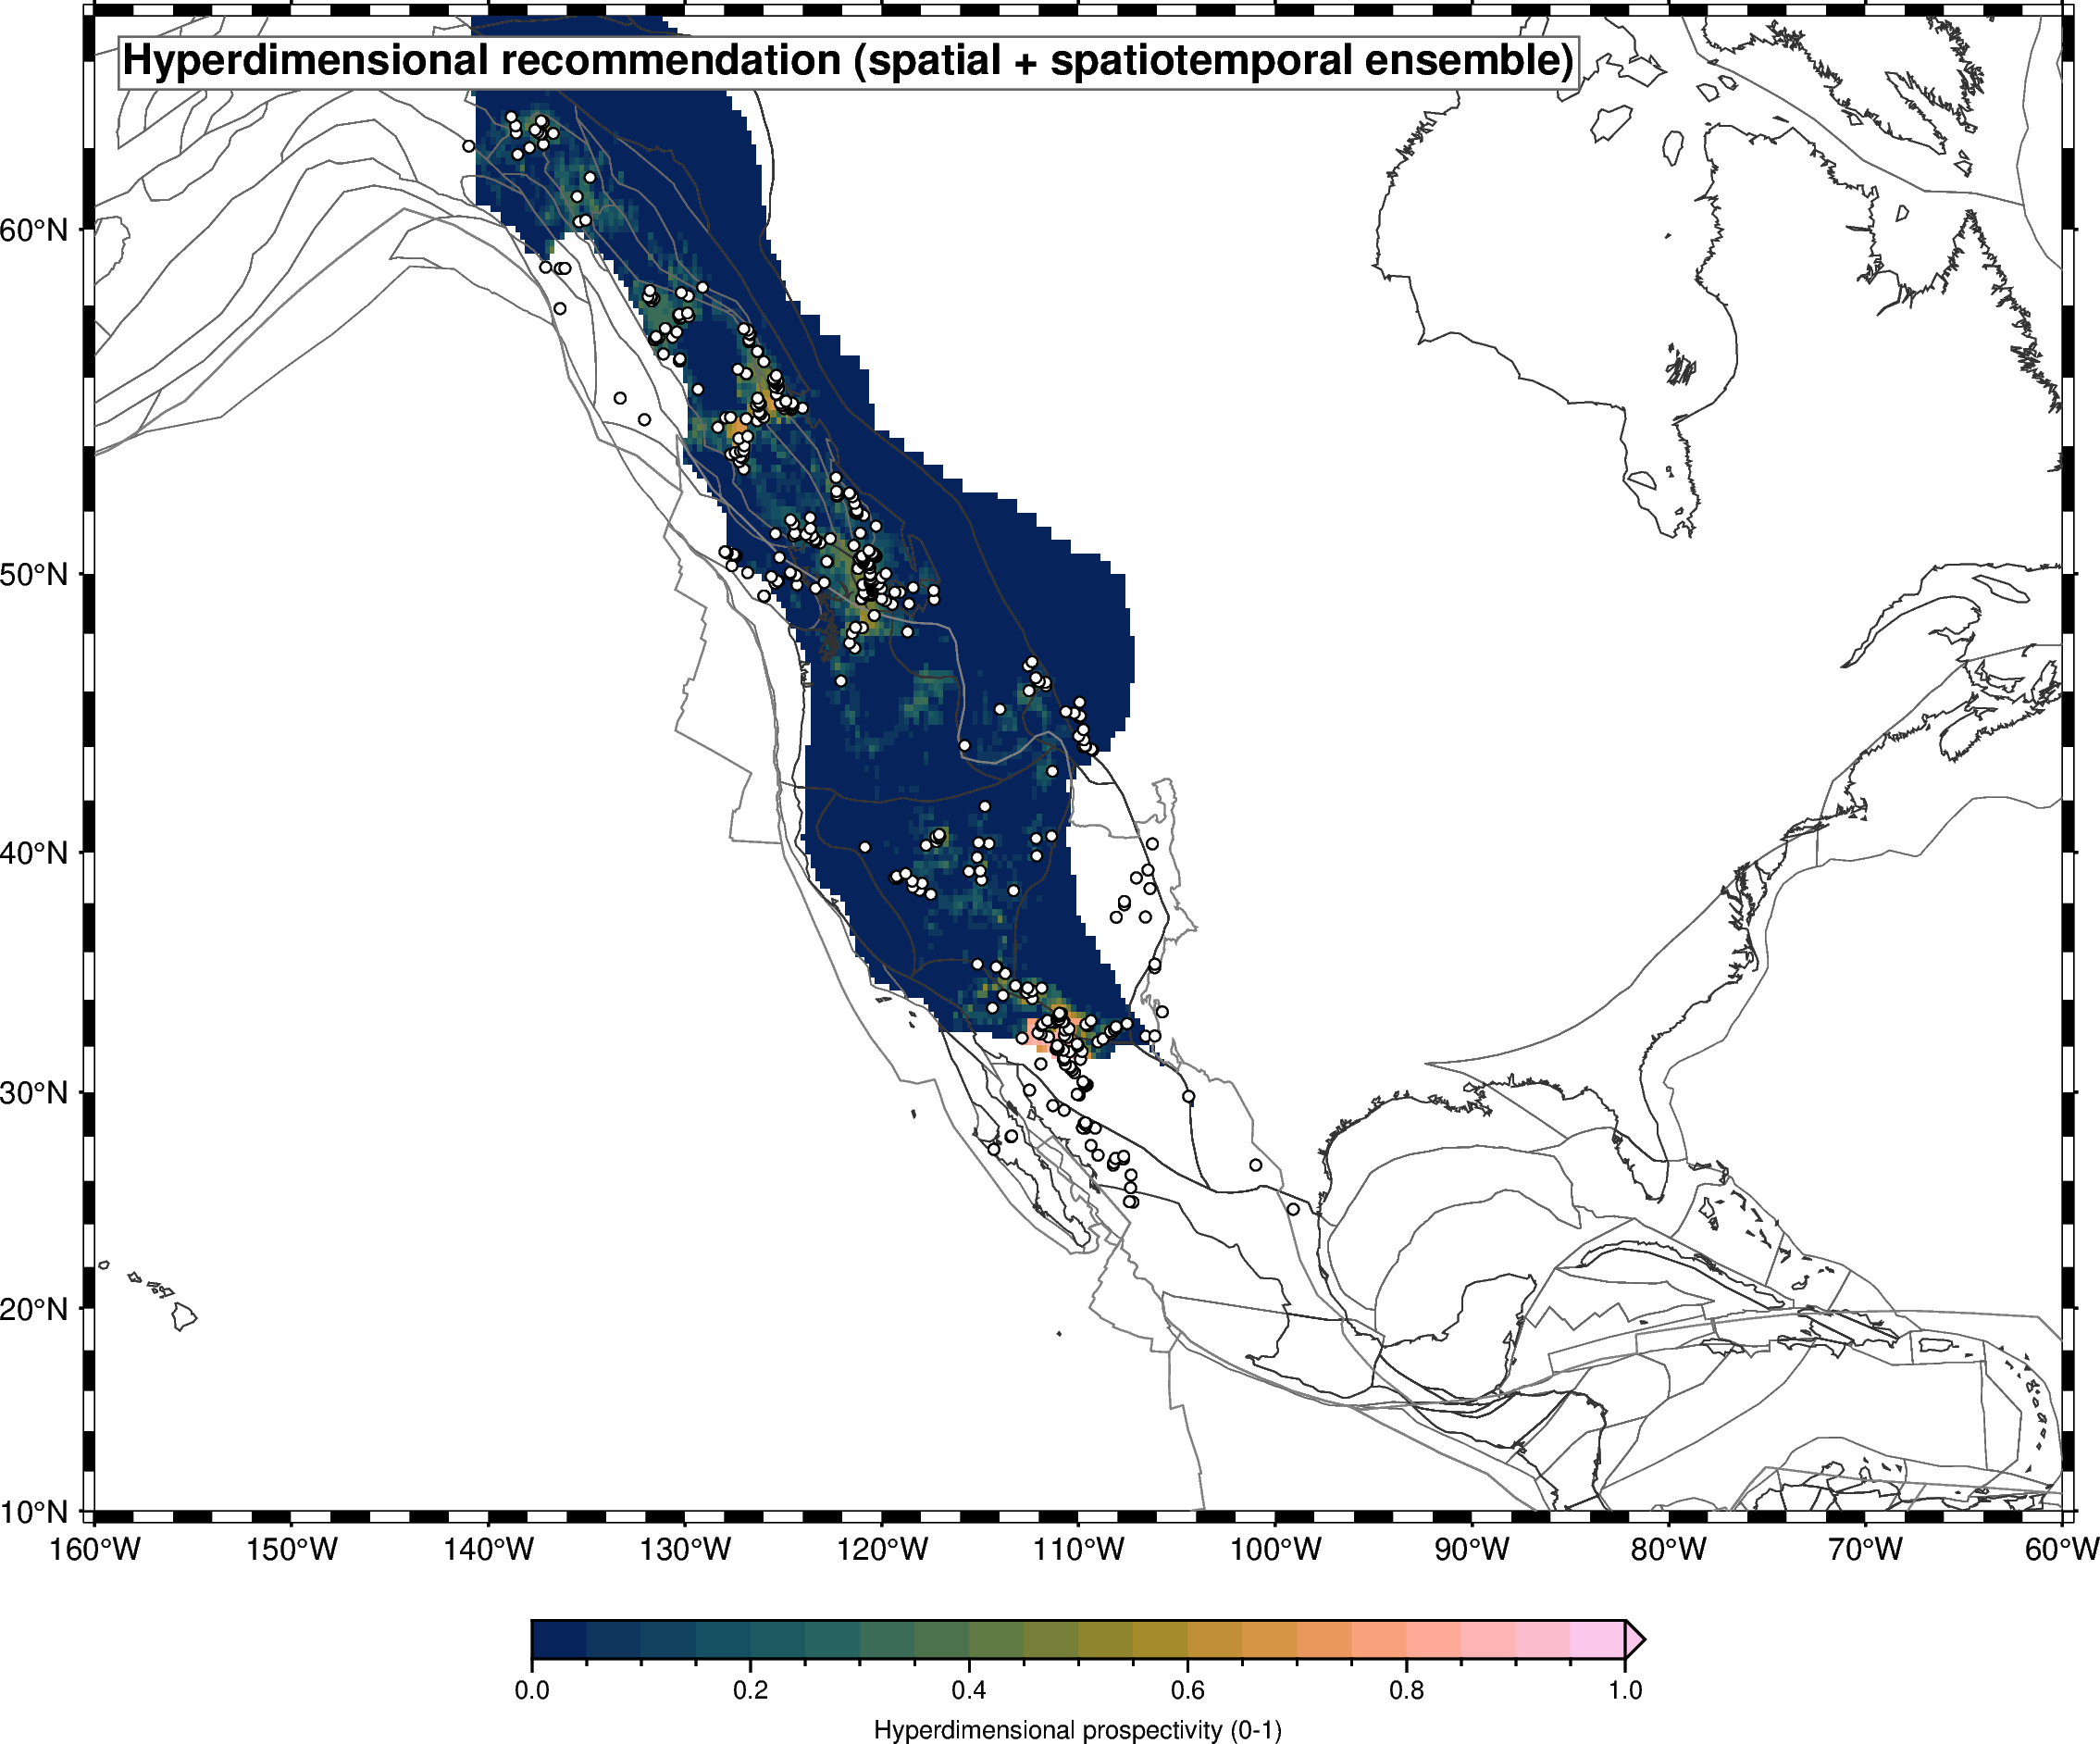

In [6]:
_ds = xr.open_dataset(HYPERDIMENSIONAL_NC)
_vn = list(_ds.data_vars)[0]
hyper_da = _ds[_vn]
print(f"  hyperdimensional: shape={hyper_da.shape}, "
      f"finite={int(np.isfinite(hyper_da.values).sum()):,} pixels, "
      f"range=[{float(hyper_da.min()):.3f}, {float(hyper_da.max()):.3f}]")

fig = pygmt.Figure()
fig.basemap(region=REGION_CORDILLERA, projection="M18c", frame="af")

pygmt.makecpt(cmap="batlow",
               series=[0, PROS_CPT_MAX, PROS_CPT_STEP],
               background="o")
try:
    fig.grdimage(grid=hyper_da, cmap=True, nan_transparent=True)
except Exception as e:
    print(f"  (skip grdimage: {type(e).__name__})")

try:
    gplot_0.plot_continents(fig, fill=None, pen="0.3p,gray40")
    gplot_0.plot_coastlines(fig, pen="0.35p,gray20")
    gplot_0.plot_all_topological_sections(fig, pen="0.4p,gray50")
    (_tl, _tr) = gplot_0.get_subduction_direction()
    gplot_0.plot_subduction_zones(fig, _tl, _tr, color="red")
except Exception as e:
    print(f"  (skip continent overlay: {type(e).__name__})")

# All 397 deposits at PRESENT-DAY positions (this is a modern exploration map)
fig.plot(x=deposits["longitude"], y=deposits["latitude"],
          style="c0.10c", fill="white", pen="0.4p,black")

fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1c+ef",
              frame=["xa0.2f0.05+lHyperdimensional prospectivity (0-1)"])

fig.text(text=f"Hyperdimensional recommendation (spatial + spatiotemporal ensemble)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.show(width=1100)


### How to read this map

- **Batlow raster** — the paper's operational HYPERDIMENSIONAL prospectivity score, an ensemble of the SPATIAL and SPATIOTEMPORAL model outputs. A cell is highlighted if EITHER model finds it prospective (union-of-evidence).
- **White dots** — all 397 known deposits at their **present-day** coordinates. This is a modern exploration map, so deposits are shown where an explorer would encounter them today.

**What it means**

This is the map an exploration geologist would actually use to prioritise fieldwork. It captures both:

1. Places where MODERN features flag prospectivity (spatial model — inherited from §3), AND
2. Places where PAST features flagged prospectivity that persists in the geological record (spatiotemporal model — inherited from §4).

**Watch for**

- **Bright cells WITH a nearby known deposit** — the paper's model correctly identified the known belt. Model validation.
- **Bright cells WITHOUT a nearby known deposit** — exploration targets the paper is recommending. The paper's headline scientific product.
- **Near-white cells** — inconclusive, i.e. neither model finds a compelling tectonic recipe. Not prioritised for fieldwork.


## 6. Spatiotemporal MINUS spatial: where time-integration changes the story

Subtracting the spatial map from the spatiotemporal-max map isolates cells that were prospective **at some Cenozoic age but AREN'T prospective by modern-margin features alone**. These are:

- **Legacy fertility belts** — where past subduction geometry made porphyry-Cu formation likely, and now-eroded deposits may remain to be found.
- **Exploration signal a spatial-only model MISSES** — cells that a modern-features-only model would rank low but the paper's spatiotemporal model rescues.

Positive values (red-orange) = spatiotemporal higher than spatial → time-integration helps here. Negative values (blue) = spatial higher than spatiotemporal → nothing to add from the past. Near-zero (white) = the two models agree.


  ST - Spatial: finite pixels = 7,423, range = [-0.984, 0.984]


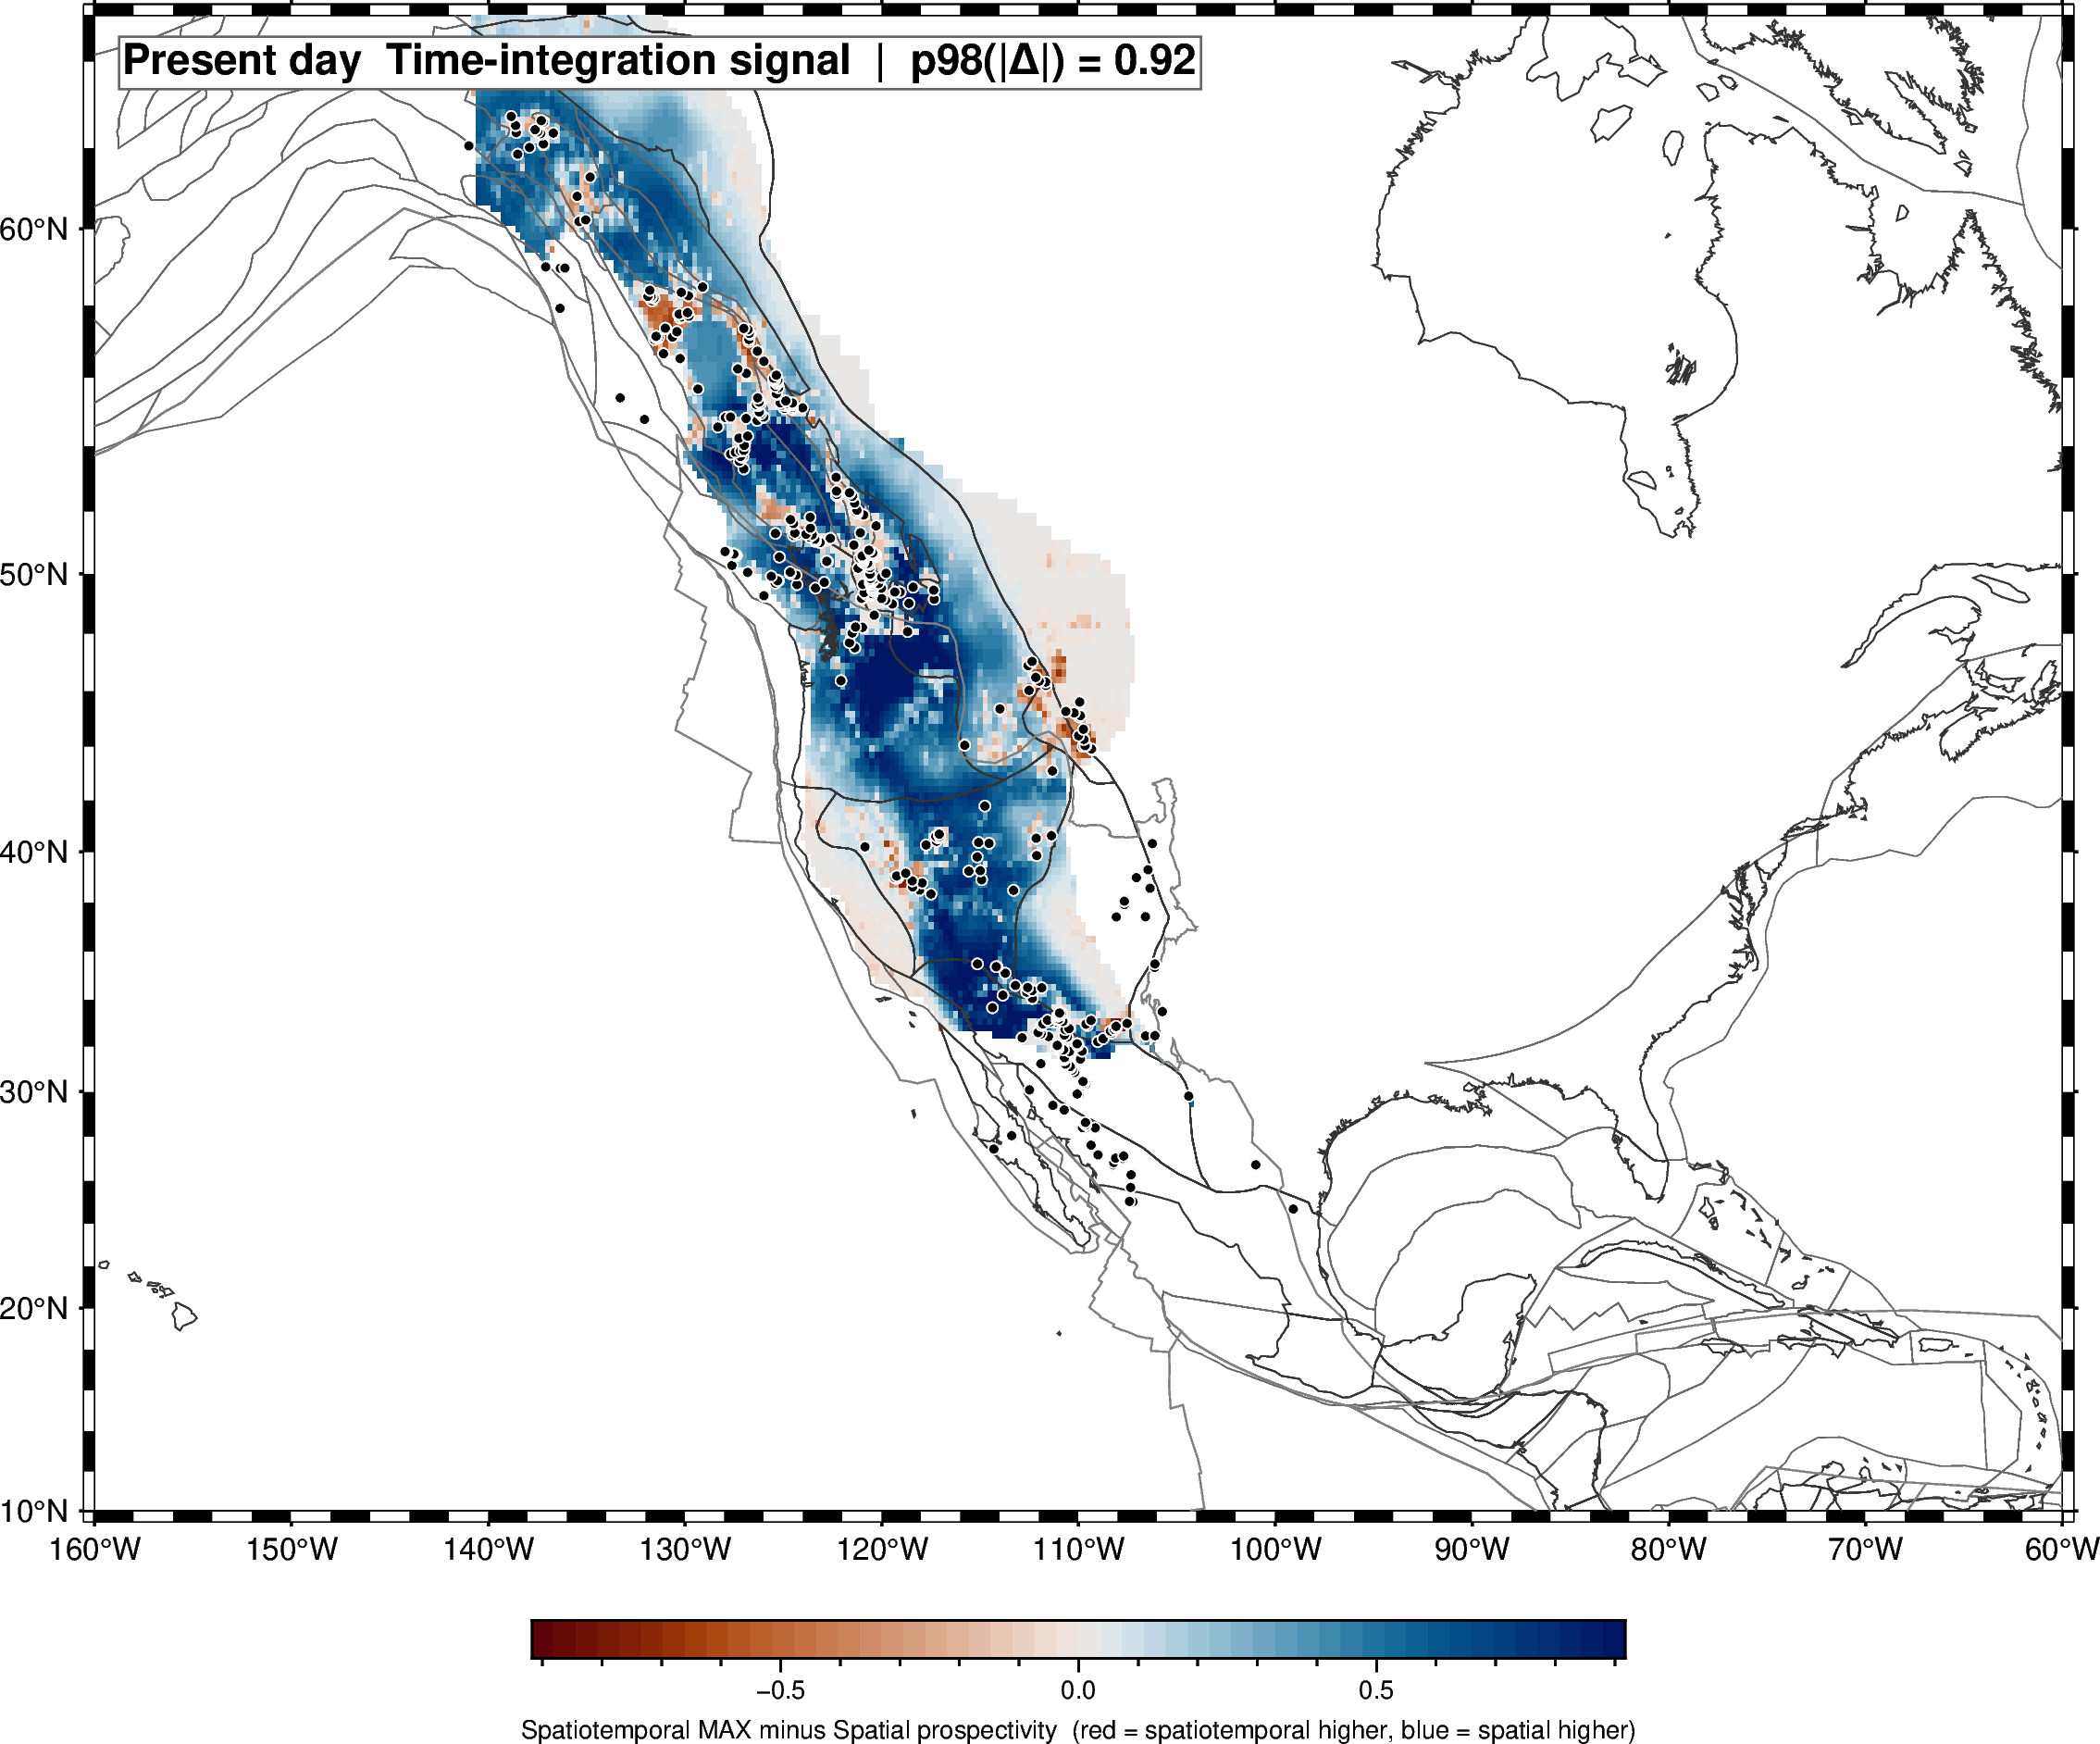

In [7]:
# Both grids need to be on the same shape. Spatial is regional NA (811x787),
# spatiotemporal is global (652x1439) — interpolate spatial onto the ST grid.
spatial_regridded = spatial_da.interp(
    Latitude=stemp_da["Latitude"],
    Longitude=stemp_da["Longitude"],
    method="linear",
)
diff_da = (stemp_da - spatial_regridded).rename("st_minus_spatial")

# Mask to cells where at least one model produced a finite value
diff_da = diff_da.where(np.isfinite(spatial_regridded) | np.isfinite(stemp_da))

finite_vals = diff_da.values[np.isfinite(diff_da.values)]
print(f"  ST - Spatial: finite pixels = {finite_vals.size:,}, "
      f"range = [{finite_vals.min():.3f}, {finite_vals.max():.3f}]")

fig = pygmt.Figure()
fig.basemap(region=REGION_CORDILLERA, projection="M18c", frame="af")

# Diverging RdBu around 0 — red = ST higher, blue = spatial higher
_max_abs = float(np.nanpercentile(np.abs(finite_vals), 98))
pygmt.makecpt(cmap="vik", series=[-_max_abs, _max_abs, _max_abs / 25],
               background="o", reverse=True)
try:
    fig.grdimage(grid=diff_da, cmap=True, nan_transparent=True)
except Exception as e:
    print(f"  (skip grdimage: {type(e).__name__})")

try:
    gplot_0.plot_continents(fig, fill=None, pen="0.3p,gray40")
    gplot_0.plot_coastlines(fig, pen="0.35p,gray20")
    gplot_0.plot_all_topological_sections(fig, pen="0.4p,gray50")
except Exception as e:
    print(f"  (skip continent overlay: {type(e).__name__})")

fig.plot(x=deposits["longitude"], y=deposits["latitude"],
          style="c0.10c", fill="black", pen="0.3p,white")

fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1c",
              frame=[f"xaf+lSpatiotemporal MAX minus Spatial prospectivity  (red = spatiotemporal higher, blue = spatial higher)"])

fig.text(text=f"Present day  Time-integration signal  |  p98(|Δ|) = {_max_abs:.2f}",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.show(width=1100)


### How to read this map — and what "spatiotemporal recovers", "modern-only recommendation", etc. mean

- **Diverging polar raster** — the value at each grid cell is *SPATIOTEMPORAL MAX − SPATIAL*. Both are 0-1 prospectivity scores, so the difference is bounded roughly ±1.
    - **Red (positive)** — SPATIOTEMPORAL is higher than SPATIAL. The cell was fertile at some Cenozoic age but wouldn't be flagged by modern-margin features alone. Informally: **"spatiotemporal recovers past fertility that the spatial-only view misses"** — hence the "ST recovers" shorthand in some of the paper's figure legends.
    - **Blue (negative)** — SPATIAL is higher than SPATIOTEMPORAL. Modern features suggest fertility but no Cenozoic age brought that cell up to a similar peak Prospectivity Score.
    - **White (near zero)** — the two models agree.
- **Black dots** — all 397 known deposits at their present-day coordinates. (Deposits are at present-day here because §6 is a map about present-day recommendations, comparing what the two models say NOW.)
- **p98(|Δ|)** in the title — 98th percentile of the absolute difference across all valid pixels; sets the symmetric ±range of the diverging colour bar so the display isn't dominated by a few extreme cells.

**What it means**

This map isolates where **time-integration changes the exploration recommendation**. Red patches with known deposits reassure the modeller: the spatiotemporal model correctly rescues that belt. Red patches WITHOUT known deposits are the interesting exploration targets — the paper's argument is that these are legitimate **legacy fertility belts** hosting undiscovered mid-tier deposits that a modern-only screen misses.

**Watch for**

- **Red patches without known deposits** — the paper's under-explored targets.
- **Blue patches** — modern-only overpredictions. These might be an early exploration bias (modern kinematics happen to look right, but the deposit-forming conditions never coincided).
- **Bulk near-white** — the two models mostly agree; time-integration only matters in specific belts, not everywhere.


## 7. Success-rate curves: how quickly does each model capture known deposits?

The standard mineral-exploration evaluation. On the x-axis, cumulative fraction of the total map area ranked highest by the model. On the y-axis, cumulative fraction of known deposits captured within that top-N% area. A random model would trace the diagonal; a perfect model would jump immediately to 100% and stay there. The steeper the initial rise, the more efficiently the model concentrates exploration effort.


  spatial success-rate curve: 9 points
 Area %  Deposits Found  Success Rate %
      1              16       13.445378
      2              30       25.210084
      5              57       47.899160
     10              76       63.865546
     20             100       84.033613
     30             109       91.596639
     50             118       99.159664
     75             119      100.000000
    100             119      100.000000

  spatiotemporal success-rate curve: 9 points
 Area %  Deposits Found  Success Rate %
      1              22       21.153846
      2              45       43.269231
      5              73       70.192308
     10              84       80.769231
     20              95       91.346154
     30              97       93.269231
     50             101       97.115385
     75             103       99.038462
    100             104      100.000000


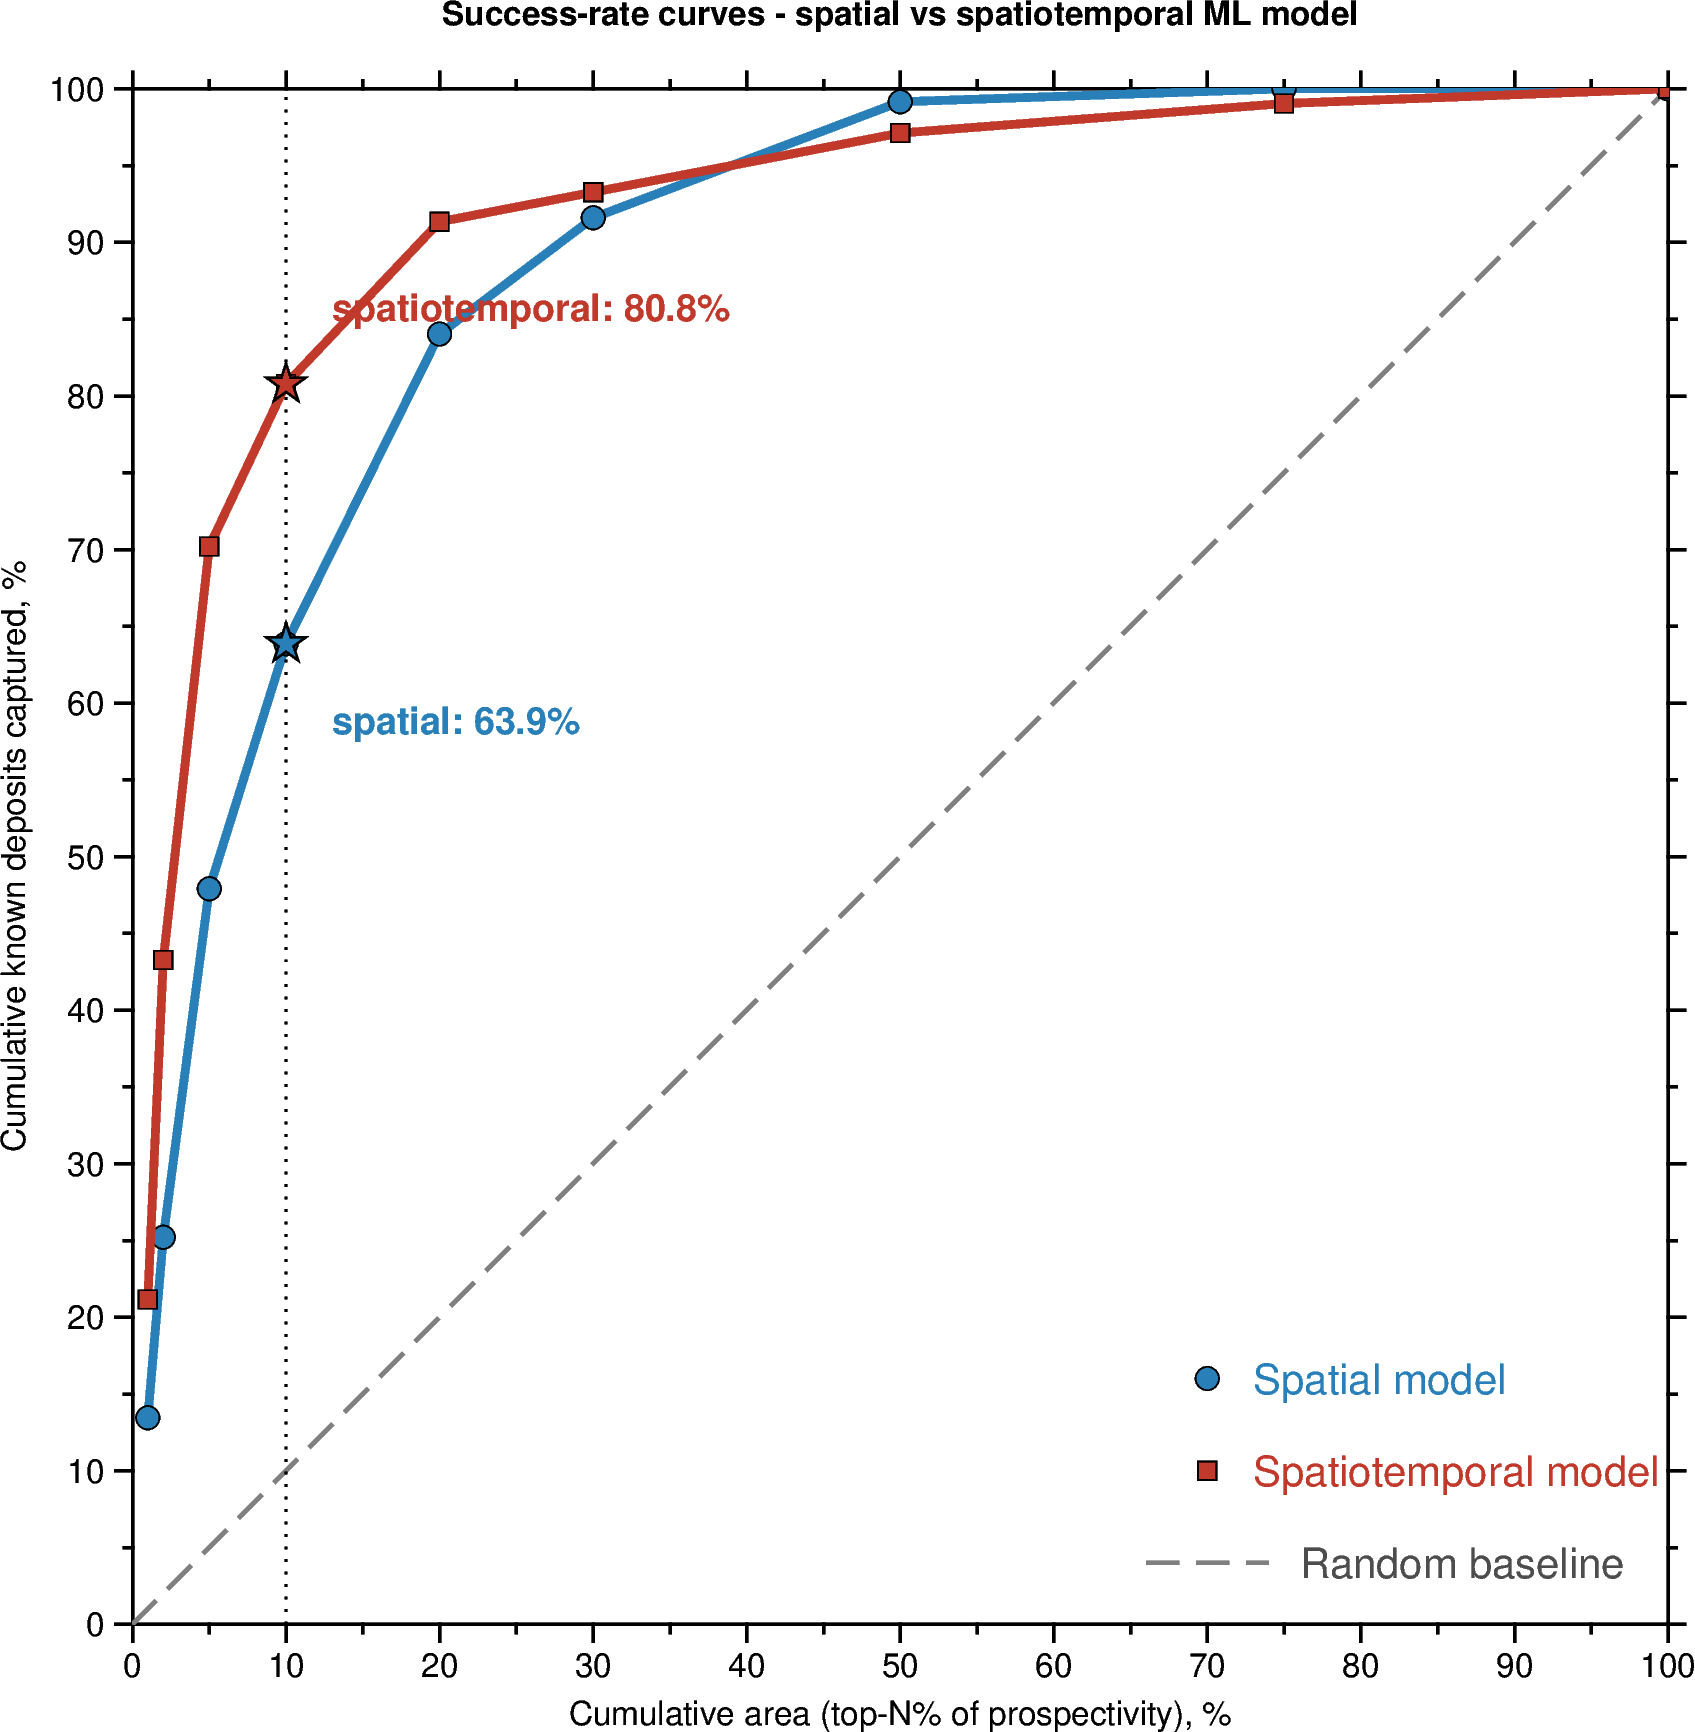

In [8]:
sp_curve = pd.read_csv(SPATIAL_SUCCESS_CSV)
st_curve = pd.read_csv(SPATIOTEMPORAL_SUCCESS_CSV)
print(f"  spatial success-rate curve: {len(sp_curve)} points")
print(sp_curve.to_string(index=False))
print(f"\n  spatiotemporal success-rate curve: {len(st_curve)} points")
print(st_curve.to_string(index=False))

fig = pygmt.Figure()
fig.basemap(region=[0, 100, 0, 100],
            projection="X13c/13c",
            frame=["WSne+tSuccess-rate curves - spatial vs spatiotemporal ML model",
                   "xa10f5+lCumulative area (top-N% of prospectivity), %",
                   "ya10f5+lCumulative known deposits captured, %"])

# Random baseline (diagonal)
fig.plot(x=[0, 100], y=[0, 100], pen="1.0p,gray50,-")

# Spatial curve
fig.plot(x=sp_curve["Area %"], y=sp_curve["Success Rate %"], pen="2p,#2980b9")
fig.plot(x=sp_curve["Area %"], y=sp_curve["Success Rate %"],
         style="c0.20c", fill="#2980b9", pen="0.3p,black")
# Spatiotemporal curve
fig.plot(x=st_curve["Area %"], y=st_curve["Success Rate %"], pen="2p,#c0392b")
fig.plot(x=st_curve["Area %"], y=st_curve["Success Rate %"],
         style="s0.22c", fill="#c0392b", pen="0.3p,black")

# 10% area vertical (paper's operational threshold)
fig.plot(x=[10, 10], y=[0, 100], pen="0.6p,black,.")

# Annotate the 10%-area success rate for each model
_r10_sp = sp_curve.loc[sp_curve["Area %"] == 10, "Success Rate %"]
_r10_st = st_curve.loc[st_curve["Area %"] == 10, "Success Rate %"]
if len(_r10_sp):
    _v = float(_r10_sp.iloc[0])
    fig.plot(x=[10], y=[_v], style="a0.35c", fill="#2980b9", pen="0.5p,black")
    fig.text(x=13, y=max(_v - 5, 5), text=f"spatial: {_v:.1f}%",
             font="9p,Helvetica-Bold,#2980b9", justify="ML")
if len(_r10_st):
    _v = float(_r10_st.iloc[0])
    fig.plot(x=[10], y=[_v], style="a0.35c", fill="#c0392b", pen="0.5p,black")
    fig.text(x=13, y=min(_v + 5, 95), text=f"spatiotemporal: {_v:.1f}%",
             font="9p,Helvetica-Bold,#c0392b", justify="ML")

# Legend (bottom-right corner as text lines with coloured markers)
fig.plot(x=[70], y=[16], style="c0.20c", fill="#2980b9", pen="0.3p,black")
fig.text(x=73, y=16, text="Spatial model",
         font="10p,Helvetica,#2980b9", justify="ML")
fig.plot(x=[70], y=[10], style="s0.22c", fill="#c0392b", pen="0.3p,black")
fig.text(x=73, y=10, text="Spatiotemporal model",
         font="10p,Helvetica,#c0392b", justify="ML")
fig.plot(x=[66, 74], y=[4, 4], pen="1.0p,gray50,-")
fig.text(x=76, y=4, text="Random baseline",
         font="10p,Helvetica,gray30", justify="ML")

fig.show(width=800)


### How to read this plot

- **x-axis** — cumulative fraction of the total map area, ranked from most-prospective (left) to least-prospective (right) by each model's score.
- **y-axis** — cumulative fraction of the 397 known deposits that fall within the top-x% area.
- **Grey dashed diagonal** — the random baseline. If the model had no predictive power, capturing X% of known deposits would require covering X% of the area.
- **Blue circles + line** — SPATIAL model curve.
- **Red squares + line** — SPATIOTEMPORAL model curve.
- **Vertical dotted line at 10% area** — the paper's operational exploration-targeting threshold. Annotations spell out each model's success rate at that threshold.

**What it means**

Steeper curves = more efficient targeting. The vertical rise near x=0 is the model's ability to concentrate known deposits in the very top ranked area. A model that captured, say, 80% of deposits inside its top 10% of area is 8× better than random.

**Watch for**

- **Which curve is higher over 0-15% area** — that model is more efficient for exploration triage.
- **Whether the two curves converge at higher x** — they always do (by x = 100%, both capture 100% of deposits); the interesting comparison is the initial slope.
- **How steeply each curve rises at x = 1%** — this is the "top 1% of the map" hit rate, the tightest possible exploration budget.


## 8. Feature importance ranked by tectonic category

The paper's spatiotemporal model was trained on 31 features. Their permutation-importance scores from the paper's own training runs are already tabulated in `spatiotemporal_feature_importance.csv`, with a `group` column that clusters them into five tectonic categories:

- **Crustal Thickness** — over-riding plate architecture
- **Material Input to Trench** — subducting-plate load: carbonate, water, sediment, CO₂, seafloor age
- **Trench Kinematics** — trench-parallel and orthogonal velocities
- **Plate & Slab Kinematics** — subducting-plate absolute velocity + convergence rate + obliquity
- **Slab Geometry & Architecture** — slab dip, arc-trench distance

Bars are coloured by group so you can see at a glance whether one category dominates or whether the recipe is a mix.


  31 features
  top 5 by importance: ['Crustal Thickness Mean (m)', 'Carbonate Thickness (m)', 'Crustal Thickness Max (m)', 'Subducted Sediment Volume (m)', 'Trench Velocity Parallel (cm/yr)']


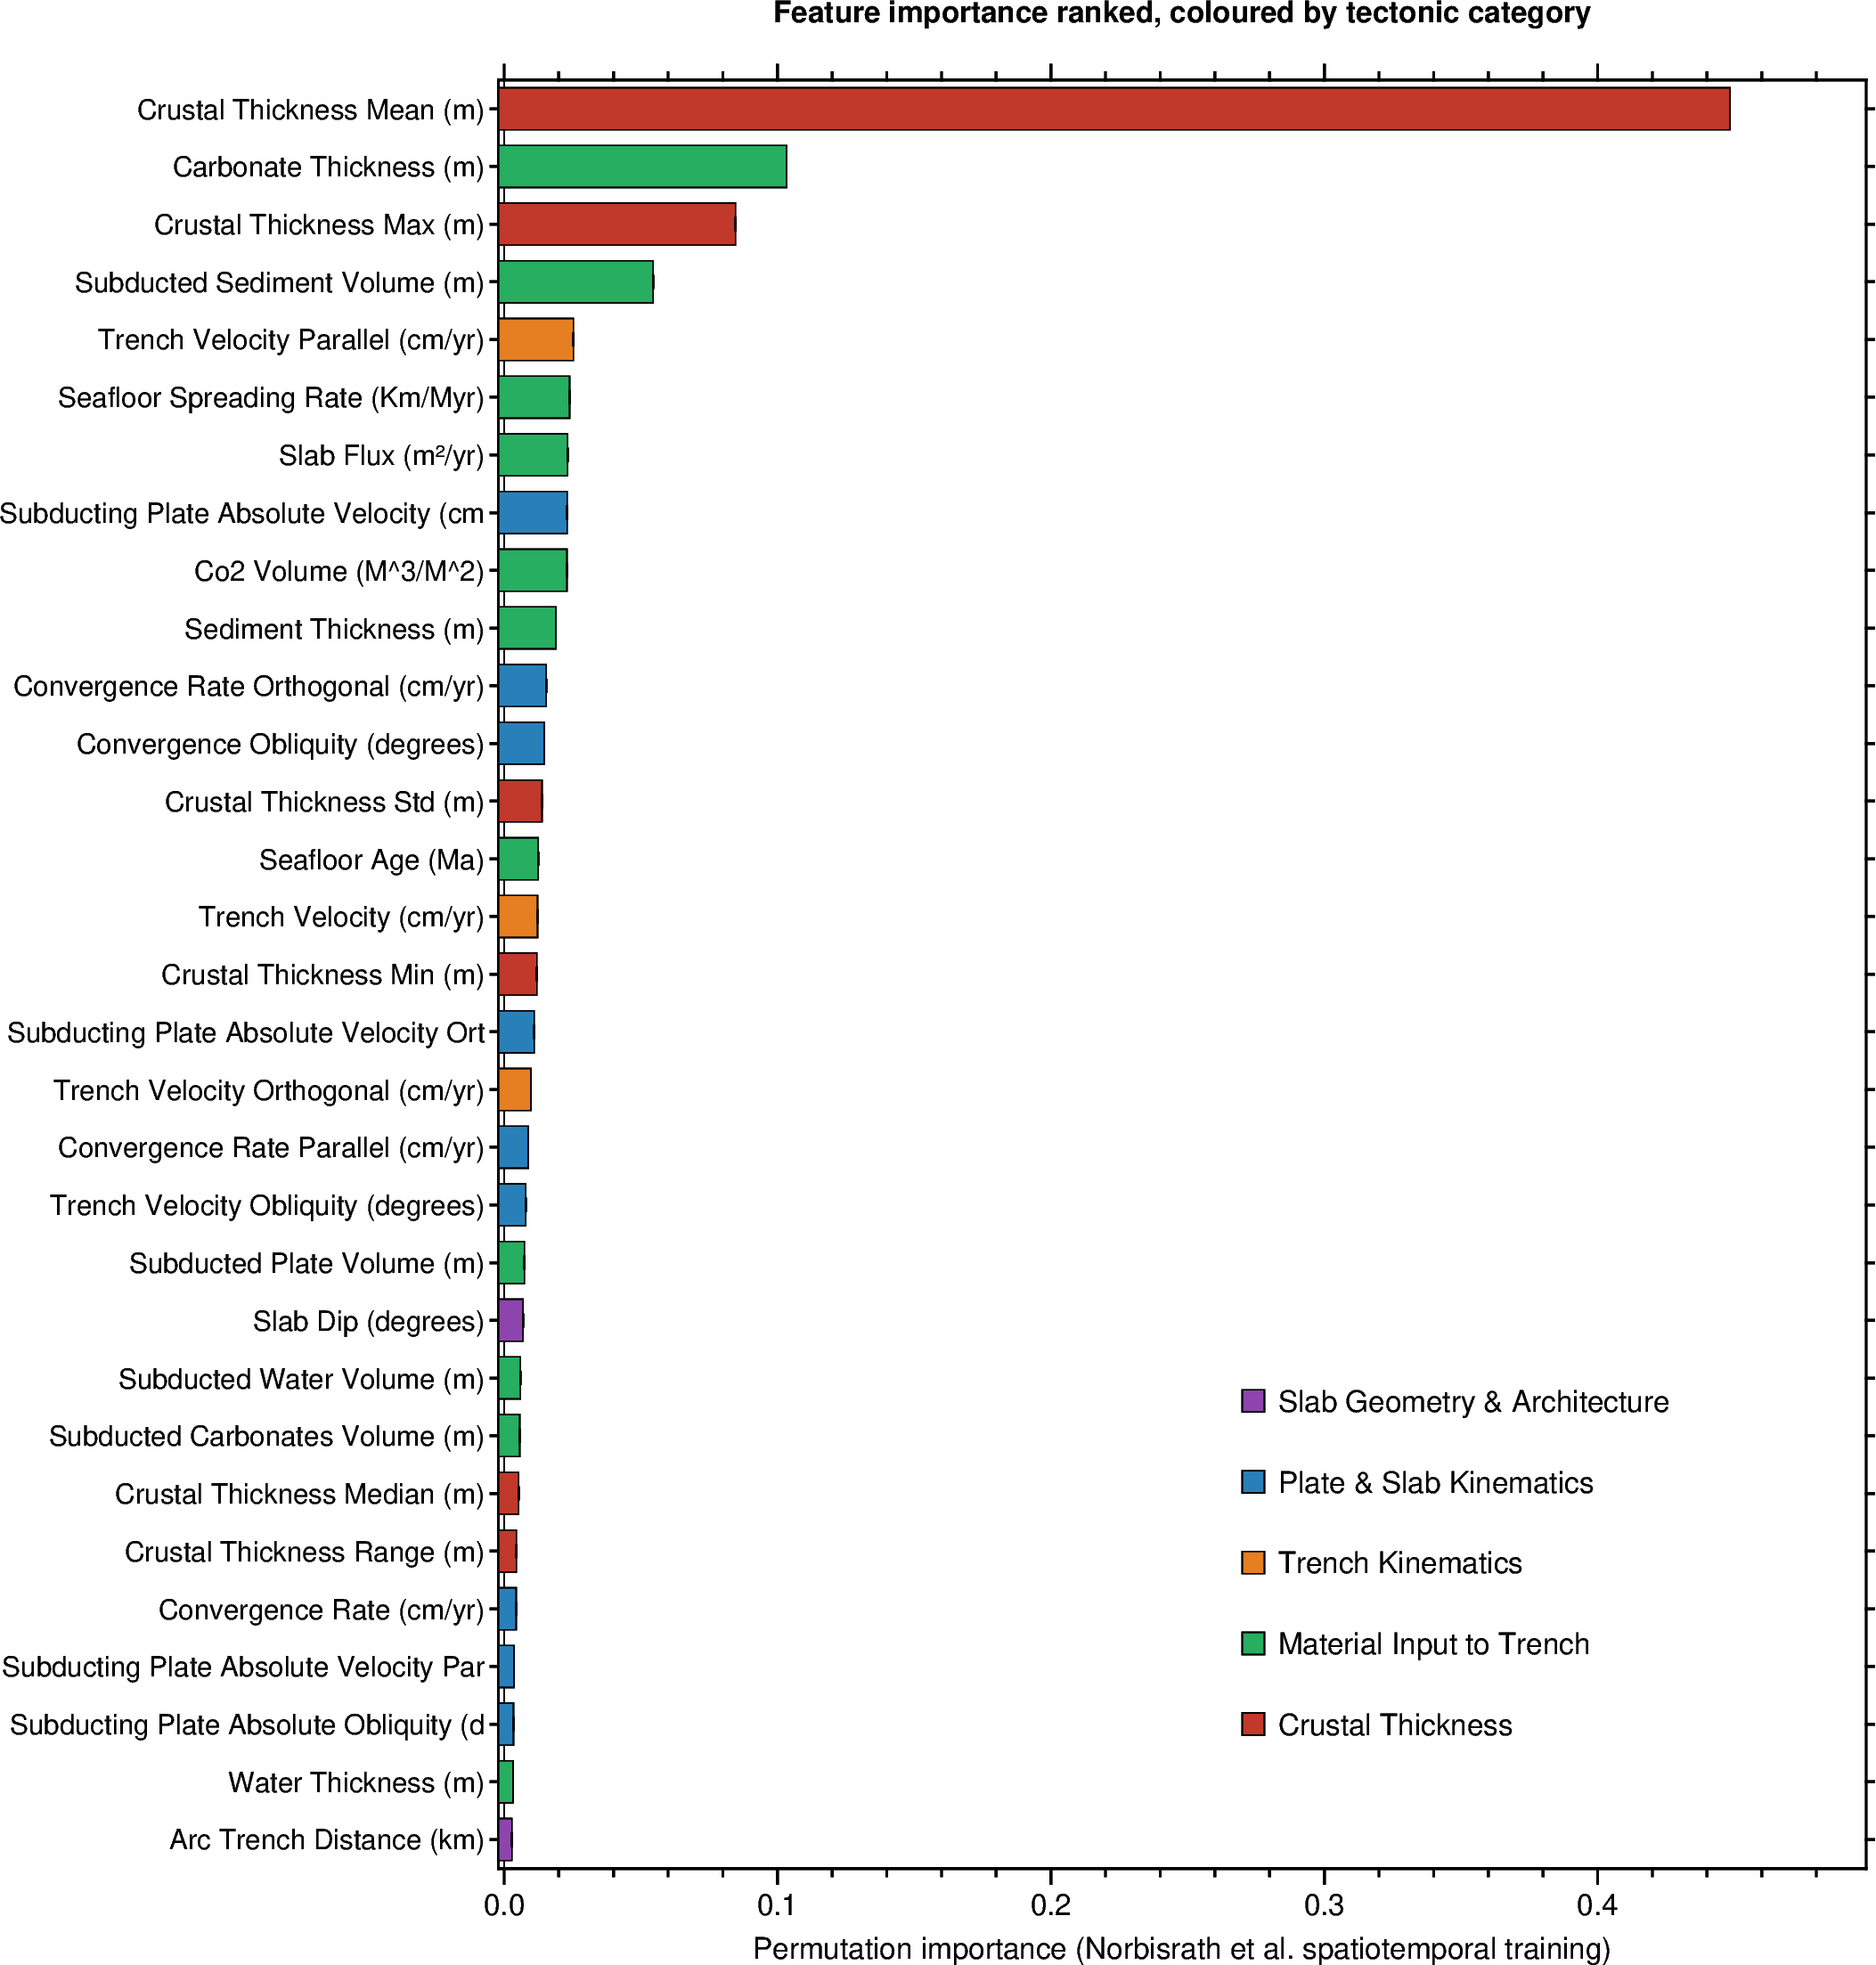


  Importance sum per tectonic group:
    Crustal Thickness                    0.5688
    Material Input to Trench             0.2818
    Plate & Slab Kinematics              0.0923
    Trench Kinematics                    0.0473
    Slab Geometry & Architecture         0.0098


In [9]:
fi = pd.read_csv(SPATIOTEMPORAL_FI_CSV).sort_values("importance_mean", ascending=True)
print(f"  {len(fi):,} features")
print(f"  top 5 by importance: {list(fi['display_name'].tail(5))[::-1]}")

# Colour per tectonic group
group_colours = {
    "Crustal Thickness":            "#c0392b",
    "Material Input to Trench":     "#27ae60",
    "Trench Kinematics":            "#e67e22",
    "Plate & Slab Kinematics":      "#2980b9",
    "Slab Geometry & Architecture": "#8e44ad",
}

_n = len(fi)
_means = fi["importance_mean"].astype(float).values
_stds  = fi["importance_std"].astype(float).values
_groups = fi["group"].astype(str).values
_names  = fi["display_name"].astype(str).values

_x_min = min(0.0, float((_means - _stds).min()) - 0.005)
_x_max = float((_means + _stds).max()) * 1.10 + 0.005

fig = pygmt.Figure()
fig.basemap(region=[_x_min, _x_max, 0.5, _n + 0.5],
            projection="X13c/17c",
            frame=["WSne+tFeature importance ranked, coloured by tectonic category",
                   "xaf+lPermutation importance (Norbisrath et al. spatiotemporal training)",
                   "yf1"])
# Zero reference
fig.plot(x=[0, 0], y=[0.5, _n + 0.5], pen="0.5p,black")

# One horizontal bar per feature (coloured by group)
for _i in range(_n):
    _y = _i + 1
    _col = group_colours.get(_groups[_i], "gray")
    fig.plot(x=[_means[_i]], y=[_y], style="B0.4c",
             fill=_col, pen="0.3p,black")
    # Error whisker
    _lo = _means[_i] - _stds[_i]
    _hi = _means[_i] + _stds[_i]
    fig.plot(x=[_lo, _hi], y=[_y, _y], pen="0.5p,black")
    _cap = 0.12
    fig.plot(x=[_lo, _lo], y=[_y - _cap, _y + _cap], pen="0.5p,black")
    fig.plot(x=[_hi, _hi], y=[_y - _cap, _y + _cap], pen="0.5p,black")
    # Feature name on the left
    fig.text(x=_x_min - (_x_max - _x_min) * 0.01, y=_y,
             text=_names[_i][:38],
             font="7.5p,Helvetica", justify="MR", no_clip=True)

# Group legend (bottom-right inside plot area)
_leg_x  = _x_max * 0.55
_leg_dx = (_x_max - _x_min) * 0.018
_leg_y0 = 3.0
for _k, (_g, _c) in enumerate(group_colours.items()):
    _y = _leg_y0 + _k * 1.4
    fig.plot(x=[_leg_x], y=[_y], style="s0.30c",
             fill=_c, pen="0.3p,black")
    fig.text(x=_leg_x + _leg_dx, y=_y, text=_g,
             font="8p,Helvetica", justify="ML")

fig.show(width=900)

print("\n  Importance sum per tectonic group:")
_by_group = fi.groupby("group")["importance_mean"].sum().sort_values(ascending=False)
for g, v in _by_group.items():
    print(f"    {g:35s}  {v:.4f}")


### What each feature means, in plain language

Norbisrath et al.'s model uses 31 features. They're grouped into five tectonic categories (matching the bar colours in the plot above); here's what each one actually measures.

**Crustal Thickness** — statistics of the over-riding continental crust in a spatial kernel around each deposit. Thick, mature continental crust traps the exsolving hydrothermal fluids at the depth where porphyry-Cu deposits form.

- *Crustal Thickness Mean* — average continental crust thickness in the kernel (m). The classical fertility control.
- *Crustal Thickness Max* — thickest crust within the kernel; captures the presence of a nearby crustal-thickness peak (root of an orogen).
- *Crustal Thickness Median* — 50th-percentile thickness; robust to outliers.
- *Crustal Thickness Min* — thinnest crust; a low value flags proximity to a rift or extended terrane.
- *Crustal Thickness Std* — standard deviation across the kernel; larger = more heterogeneous crust (terrane boundary or active deformation).
- *Crustal Thickness Range* — max minus min; another spatial-heterogeneity proxy.

**Material Input to Trench** — everything the subducting oceanic plate delivers to the arc melt column. The classical carbonate-fertility, water-hydration, and sediment-flux signals live here.

- *Carbonate Thickness* — instantaneous thickness of carbonate-rich sediments on the subducting plate at the trench (m). Direct measure of the carbonate-fertility trigger.
- *Subducted Sediment Volume* — cumulative sediment volume that has entered the trench over a time window (m). Includes carbonates and terrigenous input.
- *Sediment Thickness* — instantaneous total sediment column on the subducting plate (m).
- *Subducted Carbonates Volume* — cumulative carbonate volume entering the trench (m); differs from *Carbonate Thickness* by integrating over time rather than being a snapshot.
- *Subducted Water Volume* — water bound in the subducting slab (m water-equivalent), from altered oceanic crust + hydrated mantle + sediment porewater. Hydration of the mantle wedge drives arc magmatism.
- *Water Thickness* — instantaneous water column on the subducting plate (m).
- *CO₂ Volume* — mass of CO₂-bearing sediment per unit area (m³/m²); tracks the acid-fluid contribution to arc melts.
- *Seafloor Age* — age of the oceanic lithosphere entering the trench (Ma). Older = cooler = denser = steeper slab.
- *Seafloor Spreading Rate* — rate at which the subducting plate is being created at the spreading ridge (km/Myr).
- *Slab Flux* — mass of subducting slab entering the trench per unit trench length per unit time (m²/yr). Combines convergence rate and seafloor age.
- *Subducted Plate Volume* — cumulative volume of oceanic plate that has entered the trench over a time window (m); the time-integral of Slab Flux.

**Trench Kinematics** — how the trench itself is moving in the mantle frame. Trench advance vs roll-back sets whether the arc is compressional or extensional.

- *Trench Velocity* — absolute magnitude of trench-line motion in the mantle frame (cm/yr).
- *Trench Velocity Orthogonal* — component perpendicular to the trench (positive = advance toward subducting plate; negative = roll-back).
- *Trench Velocity Parallel* — component along the trench (trench-parallel translation).
- *Trench Velocity Obliquity* — angle between the trench-velocity vector and the trench-normal direction (degrees).

**Plate & Slab Kinematics** — how the two plates are moving relative to each other and to the deep mantle.

- *Convergence Rate* — relative velocity between subducting and over-riding plates (cm/yr). The classical measure of subduction vigour.
- *Convergence Rate Orthogonal* — component perpendicular to the trench (drives magmatism).
- *Convergence Rate Parallel* — component parallel to the trench (drives strike-slip and transpression).
- *Convergence Obliquity* — angle between the convergence-velocity vector and the trench-normal (degrees). 0° = pure head-on; 90° = pure strike-slip.
- *Subducting Plate Absolute Velocity* — velocity of the subducting plate in the mantle frame (cm/yr), independent of the over-riding plate.
- *Subducting Plate Absolute Velocity Orthogonal / Parallel* — its trench-normal and trench-parallel components.
- *Subducting Plate Absolute Obliquity* — angle relative to the trench-normal (degrees).

**Slab Geometry & Architecture** — the geometry of the descending slab, which sets where in the over-riding plate the arc lands.

- *Slab Dip* — angle between the slab and horizontal (degrees). Shallow slabs migrate the arc inland (Laramide-style flat-slab); steep slabs concentrate the arc close to the trench.
- *Arc-Trench Distance* — surface distance from the volcanic arc to the trench (km). A geometric proxy for slab depth beneath the arc + slab dip.



### What the ranking says

Norbisrath et al.'s headline finding is that the **top three features** — Crustal Thickness Mean, Carbonate Thickness, and Crustal Thickness Max — together account for well over half the total permutation importance. In tectonic terms: over-riding plate architecture (thick, mature continental crust) plus the sedimentary carbonate load on the incoming slab are the dominant fertility signals. The kinematic features (convergence rate, obliquity, trench velocity) matter, but only as a supporting cast — they're necessary conditions but not the leading indicators.

Two implications for exploration targeting:

- Regional-scale exploration in an unfamiliar belt should start with **crustal-thickness reconstructions** (from paleo-elevation + isostasy) and **paleo-subduction carbonate mass balance**, not with kinematic reconstructions alone.
- A model trained on modern-margin kinematic features WITHOUT crustal-thickness reconstructions is likely to be systematically biased — this is one reason the paper's spatiotemporal model out-performs a spatial-only baseline that reduces to modern kinematics.


## Extend this

- **Zoom out to a global map.** Change `REGION_CORDILLERA` to `REGION_GLOBAL` in the USER CONFIGURATION block and re-run §3 + §4 + §5. Both the spatiotemporal-max and hyperdimensional grids are global-coverage, so the maps will fill outside the Cordillera too — see where else the model finds prospective belts (Andes, SW-Pacific, Tethyan).
- **Compare against T77's SW-Pacific porphyry prospectivity map.** T77 (Mather et al. 2025) uses the same Alfonso 2024 plate model but a different ML architecture. Overlay the two on the SW-Pacific belt and diff them.
- **Compare against the SPATIAL feature-importance ranking.** `data/deep_time_porphyry/spatial_feature_importance.csv` is the sibling table for the spatial-only model. See which features shift rank between spatial and spatiotemporal — the ones that shift up in the spatiotemporal ranking are the ones whose temporal history matters most.
- **Run per-age spatiotemporal snapshots** using `pyDTDM.spatiotemporal_sampling` to generate a full time-series of prospectivity grids (0-90 Ma, \~5-Myr cadence). The bundled max-map is just the temporal MAX; the underlying per-age grids can be animated to show the fertility windows opening and closing across the Cenozoic. Follow the recipe in the paper's `MachineLearningModel.ipynb`.
- **Overlay non-porphyry deposit types.** Which grid cells that the model flags as prospective don't yet have a known deposit? Those are the paper's suggested exploration targets. Filter the deposits CSV by tonnage and grade to see whether the model preferentially finds the big deposits vs the small ones.

## Related resources — Geonome

The Norbisrath et al. porphyry-Cu prospectivity workflow is part of **Geonome** ([geonome.com.au](https://geonome.com.au/#home)) — an EarthByte-led open initiative for AI-driven deep-time mineral prospectivity. The tutorial companion for this exact use case lives at [geonome.com.au/tutorials/ai-mineral-prospectivity.html](https://geonome.com.au/tutorials/ai-mineral-prospectivity.html) and walks through the broader pipeline: data preparation, feature engineering, model training, and deposit-inventory management, plus the equivalent workflows for other commodity systems. This notebook only touches the visualisation + interpretation end; the Geonome tutorial covers everything upstream of it.

## References

- Norbisrath, J.H., Singh, S.P., Singh, U., Müller, R.D. (submitted 2026). *Plate reorganisation and carbonate subduction create transient porphyry copper fertility windows*. *Geology*. Data + code: PolyForm Noncommercial 1.0.0 / CC BY-NC 4.0.
- Alfonso, C.P., Müller, R.D., Cannon, J., Wright, N., Ford, J., Chin, M. (2024). A deep-time plate model of the North American Cordillera and adjacent Pacific plate system 250 Ma to present. *Earth-Science Reviews* 250, 104692.
- Hammarstrom, J.M., et al. (2010). *Global assessment of undiscovered copper resources*. USGS Scientific Investigations Report 2010-5090.
- Singer, D.A., Berger, V.I., Moring, B.C. (2008). *Porphyry copper deposits of the world: database and grade and tonnage models*. USGS Open-File Report 2008-1155.
- Mather, B.R., Müller, R.D., Alfonso, C., Wright, N.M., Seton, M. (2025). Subducting seafloor anomalies promote porphyry copper formation. *International Geology Review* 67(19), 2170-2186.
